## **Importação das bibliotecas e datasets e criação das funções**

In [1]:
import json
import os
import sys
import io
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar a seed para o Python, NumPy e TensorFlow
SEED = 42  # valor fixo que será utilizado como seed

# Seed para o Python
random.seed(SEED)

# Seed para o NumPy (usado para operações de matriz e aleatoriedade fora do TensorFlow)
np.random.seed(SEED)

# Seed para o TensorFlow
tf.random.set_seed(SEED)

In [2]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "1"
dataset_type_du = f"{agrupamento}_days_duas_unas"
#validation_method = 'split'

In [3]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [4]:
# Cria um diretório específico se não existir
diretorio_pesos_teste_1 = f"Resultados_PSO/pso_du/{agrupamento}_days/pesos/teste_1"
os.makedirs(diretorio_pesos_teste_1, exist_ok=True)

diretorio_pesos_teste_3 = f"Resultados_PSO/pso_du/{agrupamento}_days/pesos/teste_3"
os.makedirs(diretorio_pesos_teste_3, exist_ok=True)

diretorio_avaliacao_teste_0 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_0"
os.makedirs(diretorio_avaliacao_teste_0, exist_ok=True)

diretorio_avaliacao_teste_1 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_1"
os.makedirs(diretorio_avaliacao_teste_1, exist_ok=True)

diretorio_avaliacao_teste_2 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_2"
os.makedirs(diretorio_avaliacao_teste_2, exist_ok=True)

diretorio_avaliacao_teste_3 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_3"
os.makedirs(diretorio_avaliacao_teste_3, exist_ok=True)

diretorio_avaliacao_teste_4 = f"Resultados_PSO/pso_du/{agrupamento}_days/avaliacao_testes/teste_4"
os.makedirs(diretorio_avaliacao_teste_4, exist_ok=True)


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [6]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [7]:
validation_interval = config['datasets'][dataset_type_du]['timesteps'] + config['datasets'][dataset_type_du]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
horizonte = config['datasets'][dataset_type_du]['output_horizon']
#print(f'validation interval',validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
scalers = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)
    scalers.append(scaler)  # Salvar o scaler específico para este dataset

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled

In [8]:
def save_function_output(func, *args, output_file, output_dir, **kwargs):
    # Redireciona stdout para capturar os prints
    old_stdout = sys.stdout
    new_stdout = io.StringIO()
    sys.stdout = new_stdout
    
    try:
        # Executa a função e captura sua saída
        func(*args, **kwargs)
    finally:
        # Restaura stdout e captura a saída
        sys.stdout = old_stdout
        output = new_stdout.getvalue()
        
        # Cria o diretório se não existir
        os.makedirs(output_dir, exist_ok=True)
        
        # Caminho completo para o arquivo de saída
        save_path = os.path.join(output_dir, output_file)
        
        # Salva a saída em um arquivo
        with open(save_path, 'w') as f:
            f.write(output)
        print(f"Output salvo em: {save_path}")

In [9]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [10]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [11]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [12]:

def create_and_train_model(config, dataset_type, X, y, validation_method, k, tt_rate):
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    # Aplicar o método de validação
    if validation_method == 'split':
        # Usar validação por divisão
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=tt_rate, random_state=42)
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        callbacks=[early_stopping])
        
        # Ajuste do gráfico para começar em 1
        epochs_range = range(1, len(history.history['loss']) + 1)
        
        plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
        plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
        plt.xlabel('Épocas')
        plt.ylabel('Perda')
        plt.legend()
        plt.show()

    elif validation_method == 'k-fold':
    # Usar validação k-fold
    
        kf = KFold(n_splits=min(k, len(X)), shuffle=False)  # shuffle=False para manter a sequência temporal
        for train_index, val_index in kf.split(X):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]
            history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                            callbacks=[early_stopping])
        
            # Ajuste do gráfico para começar em 1
            epochs_range = range(1, len(history.history['loss']) + 1)

            plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
            plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
            plt.xlabel('Épocas')
            plt.ylabel('Perda')
            plt.legend()
            plt.show()

    return model

In [13]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [14]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [15]:
# Carregar os pesos salvos
def carregar_pesos(arquivo_pesos_camada):

  with np.load(arquivo_pesos_camada) as data:
      W = data['arr_0']
      U = data['arr_1']
      b = data['arr_2']
      # Os pesos podem ter mais de um conjunto, então você deve garantir que a ordem e o número estejam corretos.
      loaded_weights = [W, U, b]
      print(W.shape)
      print(U.shape)
      print(b.shape)
  return loaded_weights

In [16]:
def carregar_e_aplicar_pesos(lstm_model, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3):
    
    pesos_LSTM1_t1_carregado = carregar_pesos(caminho_LSTM1)
    pesos_LSTM2_t1_carregado = carregar_pesos(caminho_LSTM2)
    #pesos_LSTM3_t1_carregado = carregar_pesos(caminho_LSTM3)

    # Aplicar os pesos carregados à camada LSTM
    lstm_model.get_layer(index=0).set_weights(pesos_LSTM1_t1_carregado)
    lstm_model.get_layer(index=2).set_weights(pesos_LSTM2_t1_carregado)
    #lstm_model.get_layer(index=4).set_weights(pesos_LSTM3_t1_carregado)

In [17]:
# Congela as três primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def congelar_camadas(lstm_model):
#lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = False
    lstm_model.layers[2].trainable = False
    #lstm_model.layers[4].trainable = False
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [18]:
# Descongela as duas primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def descongelar_camadas(lstm_model):
    #lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = True
    lstm_model.layers[2].trainable = True
    #lstm_model.layers[4].trainable = True
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [19]:
# Automatizar os splits de treino/teste
current_filename = None
resultados = []  # Para armazenar os resultados de cada execução
def salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation):
    global current_filename, resultados
    
    # Se o nome do arquivo mudou, salvar os resultados e reiniciar a lista
    if current_filename != diretorio:
        # Atualiza o nome do arquivo atual e reinicia a lista de resultados
        current_filename = diretorio
        resultados = []  # Reinicia a lista de resultados
    
    # Armazenar os resultados
    resultados.append({
        'validation': validation,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'accuracy 2%': acuracia_2,
        'accuracy 5%': acuracia_5,
        'accuracy 10%': acuracia_10,
        'Erro percentual acumulado 30 dias': err_perc_acum_30dias,
        'Erro percentual acumulado 60 dias': err_perc_acum_60dias,
        'Erro percentual acumulado 90 dias': err_perc_acum_90dias,
        'Erro percentual acumulado 1º mês': err_perc_acum_pri_mes,
        'Erro percentual acumulado 2º mês': err_perc_acum_seg_mes,
        'Erro percentual acumulado 3º mês': err_perc_acum_ter_mes
         
        
    })
            
    # Salvar os resultados em um arquivo CSV
    results_df = pd.DataFrame(resultados)
    results_df.to_csv(f'{diretorio}/results.csv', index=False)
    print('Terminada sequencia de testes')

In [20]:
def avaliacao_multistep(janela_real, janela_prevista, diretorio, validation):

    
    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    # Converte para arrays 1D, se necessário
    janela_real = np.array(janela_real).reshape(-1)
    janela_prevista = np.array(janela_prevista).reshape(-1)
    
    # print(janela_real)
    # print(" ")
    # print(janela_prevista)
    # print(" ")

    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)

    # Calcula a acurácia com a contagem de acertos entre 0 e 100%
    acuracia_2 = round(100 * (np.sum(diferencas_percentuais <= 0.02) / len(janela_real)), 2)
    acuracia_5 = round(100 * (np.sum(diferencas_percentuais <= 0.05) / len(janela_real)), 2)
    acuracia_10 = round(100 * (np.sum(diferencas_percentuais <= 0.1) / len(janela_real)), 2)

            
    print("2% Accuracy Score of LSTM model = ",acuracia_2)
    print("5% Accuracy Score of LSTM model = ",acuracia_5)
    print("10% Accuracy Score of LSTM model = ",acuracia_10)
    print(" ")
    
    if agrupamento == '1':
        h_1mes = 30
        h_2mes = 60
        
    elif agrupamento == '3':
        h_1mes = 10
        h_2mes = 20

    else:
        h_1mes = 4
        h_2mes = 8

    acumulado_1mes_real = janela_real[:h_1mes].sum()
    # print("acumulado_1mes_real", acumulado_1mes_real)
    acumulado_1e2mes_real = janela_real[:h_2mes].sum()
    # print("acumulado_1e2mes_real", acumulado_1e2mes_real)
    acumulado_1e2e3mes_real = janela_real[:].sum()
    # print("acumulado_1e2e3mes_real", acumulado_1e2e3mes_real)
    acumulado_2mes_real = janela_real[h_1mes:h_2mes].sum()
    # print("acumulado_2mes_real", acumulado_2mes_real)
    acumulado_3mes_real = janela_real[h_2mes:].sum()
    # print("acumulado_3mes_real", acumulado_3mes_real)

    acumulado_1mes_pred = janela_prevista[:h_1mes].sum()
    # print("acumulado_1mes_pred", acumulado_1mes_pred)
    acumulado_1e2mes_pred = janela_prevista[:h_2mes].sum()
    # print("acumulado_1e2mes_pred", acumulado_1e2mes_pred)
    acumulado_1e2e3mes_pred = janela_prevista[:].sum()
    # print("acumulado_1e2e3mes_pred", acumulado_1e2e3mes_pred)
    acumulado_2mes_pred = janela_prevista[h_1mes:h_2mes].sum()
    # print("acumulado_2mes_pred", acumulado_2mes_pred)
    acumulado_3mes_pred = janela_prevista[h_2mes:].sum()
    # print("acumulado_3mes_pred", acumulado_3mes_pred)
    
    err_perc_acum_30dias = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_60dias = round(((abs(acumulado_1e2mes_real-acumulado_1e2mes_pred))/acumulado_1e2mes_real)*100, 2)
    err_perc_acum_90dias = round(((abs(acumulado_1e2e3mes_real-acumulado_1e2e3mes_pred))/acumulado_1e2e3mes_real)*100, 2)
    err_perc_acum_pri_mes = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_seg_mes = round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2)
    err_perc_acum_ter_mes = round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2)

    print("Erro %. acum 30 dias:", err_perc_acum_30dias,"%")
    print("Erro %. acum 60 dias:", err_perc_acum_60dias,"%")
    print("Erro %. acum 90 dias:", err_perc_acum_90dias,"%")
    print(" ")
    print("Erro %. acum 1º mês:", err_perc_acum_pri_mes,"%")
    print("Erro %. acum 2º mês:", err_perc_acum_seg_mes,"%")
    print("Erro %. acum 3º mês:", err_perc_acum_ter_mes,"%")
    
    salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation)
    
    return

In [21]:
def results(model, validation_dataset_scaled, validation_method, diretorio, validation):
    pred = model.predict(validation_dataset_scaled.iloc[0])
    y_pred_rescaled = scalers[4].inverse_transform(pred)
    y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
    duas_unas_validation_rescaled = scalers[4].inverse_transform(validation_dataset_scaled[1:])

    plt.figure(figsize=(14,6))
    plt.plot(validation_dataset_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
    plt.plot(validation_dataset_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
    plt.yticks(np.arange(0,25000,step=5000))
    plt.title("DATASET TESTE")

        # Nome do arquivo incluindo a variável 'validation_method'
    file_name = f'prediction_plot_with_method_{validation_method}_{validation}.png'

    # Caminho completo para salvar o arquivo
    save_path = os.path.join(diretorio, file_name)

    # Salvar o plot
    plt.savefig(save_path)
    plt.show()
    
    
    #avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio, validation)

    # Nome do arquivo incluindo a variável 'validation_method'
    output_file = f'avaliacao_with_method_{validation_method}_{validation}.txt'
    
    save_function_output(avaliacao_multistep, 
                        duas_unas_validation_rescaled, 
                        y_pred_rescaled,
                        diretorio,
                        validation, 
                        output_file = output_file, 
                        output_dir=diretorio)

In [22]:
from tensorflow.keras.initializers import HeNormal
def transfer_learning_model(config, model, diretorio_pesos, diretorio_resultados, teste, validation_method, k):
    
    # Salvamento dos pesos após primeiro treinamento
    pesos_treinamento = model.get_weights()
    pesos_LSTM1 = model.layers[0].get_weights()
    pesos_LSTM2 = model.layers[2].get_weights()
    pesos_LSTM3 = model.layers[4].get_weights()
    pesos_DENSE = model.layers[6].get_weights()

    # Salvar pesos de cada camada LSTM em arquivos .npz
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM1)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM2)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM3)
    np.savez(os.path.join(diretorio_pesos, f'pesos_DENSE_{teste}_{validation_method}_{k}.npz'), *pesos_DENSE)

    # Para salvar os pesos do modelo completo
    np.savez(os.path.join(diretorio_pesos, f'pesos_modelo_{teste}_{validation_method}_{k}.npz'), *pesos_treinamento)

    # # Carregar pesos do arquivo .npz
    # pesos_carregados_LSTM1 = np.load(os.path.join(diretorio, f'pesos_LSTM1_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM2 = np.load(os.path.join(diretorio, f'pesos_LSTM2_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM3 = np.load(os.path.join(diretorio, f'pesos_LSTM3_{teste}_{validation_method}.npz'))
    
    
    X, y = create_dataset(scaled_datasets[4], config['datasets'][dataset_type_du]['timesteps'], config['datasets'][dataset_type_du]['output_horizon'])
    X = X.reshape(X.shape[0], X.shape[1], 1)

    model_ft = Sequential()

    for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
        model_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model_ft.add(Dropout(0.3))

    model_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type_du]['activation']))

    model_ft.summary()
    
    
    # Caminho dos pesos salvos
    caminho_LSTM1 = os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM2 = os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM3 = os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz')

    carregar_e_aplicar_pesos(model_ft, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3)
        
    congelar_camadas(model_ft)
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 1-k, random_state=42)

    learning_rate = config['datasets'][dataset_type_du]['learning_rate']

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type_du]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model_ft.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=4, restore_best_weights=True) 

    history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])
        
    # Ajuste do gráfico para começar em 1
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()
    
    # descongelar_camadas(model_ft)

    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

    # learning_rate = 0.0008

    # # Configurar o otimizador
    # optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    # if optimizer == 'adam':
    #     opt = Adam(learning_rate=learning_rate)
    # elif optimizer == 'rmsprop':
    #     opt = RMSprop(learning_rate=learning_rate)
    # else:
    #     opt = SGD(learning_rate=learning_rate)

    # # Configurar a função de perda
    # loss_function = config['datasets'][dataset_type_du]["loss_function"]

    # if loss_function == "wmae":
    #     loss = wmae
    # elif loss_function == "wmse":
    #     loss = wmse

    # model_ft.compile(optimizer=opt, loss=loss)

    # early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

    # history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
    #                 callbacks=[early_stopping])
        
    # # Ajuste do gráfico para começar em 1
    # epochs_range = range(1, len(history.history['loss']) + 1)

    # plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    # plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    # plt.xlabel('Épocas')
    # plt.ylabel('Perda')
    # plt.legend()
    plt.show()

    results(model_ft, duas_unas_validation_scaled, validation_method, diretorio_resultados, k)

## **TESTE 00A**
Dataset Duas Unas.

Teste tradicional do modelo sem otimização PSO e treinado apenas pelo dataset Duas Unas.

In [23]:
### DATASETS PARA TESTE 00 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0A = concatenate_selected_datasets(scaled_datasets, indices)

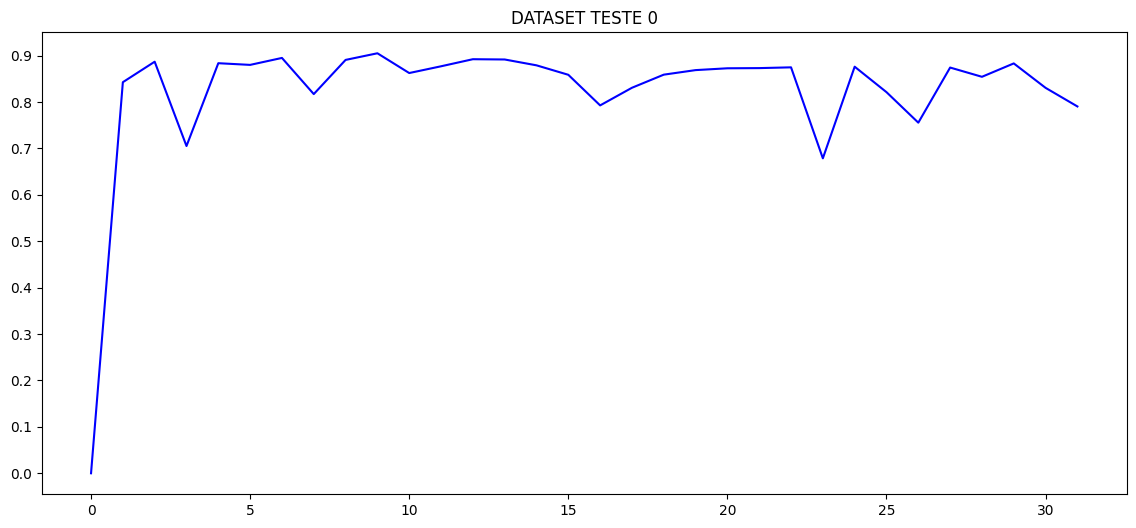

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0A, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 0")
plt.show()

X shape (20, 1)
y shape (20, 12)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 100)         │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,812 (792.23 KB)

 Trainable params: 202,812 (792.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.7322 - val_loss: 0.6886
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step - loss: 0.6945 - val_loss: 0.6342
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 0.6365 - val_loss: 0.5524
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.5509 - val_loss: 0.4314
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.4185 - val_loss: 0.2675
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.2287 - val_loss: 0.0941
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0592 - val_loss: 0.0755
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0944 - val_loss: 0.1360
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.2405 - val_loss: 0.0625
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0767 - val_loss: 0.0279
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 0.0194 - val_loss: 0.0427
Epoch 12/100000
1/1 ━━━━━━━━━━━

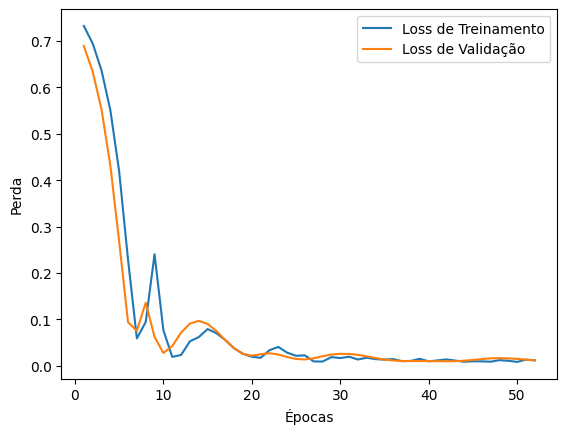

In [25]:
from tensorflow.keras.losses import MeanSquaredError
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_0, y_0 = create_dataset(dataset_test_0A, timesteps, output_steps)
X_0 = X_0.reshape(X_0.shape[0], X_0.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(X_0, y_0, test_size=0.2, random_state=42)

model0A = Sequential()

                                                          #X_train.shape[1]
model0A.add(LSTM(100,return_sequences=True, input_shape=(X_0.shape[1], 1))) # Apenas a primeira camada informa input_shape. As demais fazem inferência
model0A.add(Dropout(0.3)) # Taxa de atenuação aplicada à saída para evitar overfitting - Elimina aleatoriamente alguns neurônios

model0A.add(LSTM(100,return_sequences=True))
model0A.add(Dropout(0.3))

model0A.add(LSTM(100,return_sequences=False)) #Anteriormente era FALSE. Foi alterado devido à adição da camada Attention
model0A.add(Dropout(0.3))

model0A.add(Dense(config['datasets'][dataset_type_du]['output_horizon'])) # Dense - Camada totalmente conectada com dimensionalidade de saída igual a 1

model0A.summary() # Printa um sumário da rede

model0A.compile(optimizer=Adam(learning_rate=0.01), loss=MeanSquaredError)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True)

history = model0A.fit(X_train, y_train, batch_size=16, epochs=100000, validation_data=(X_test, y_test), 
                callbacks=[early_stopping])
    
# Ajuste do gráfico para começar em 1
epochs_range = range(1, len(history.history['loss']) + 1)

plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step


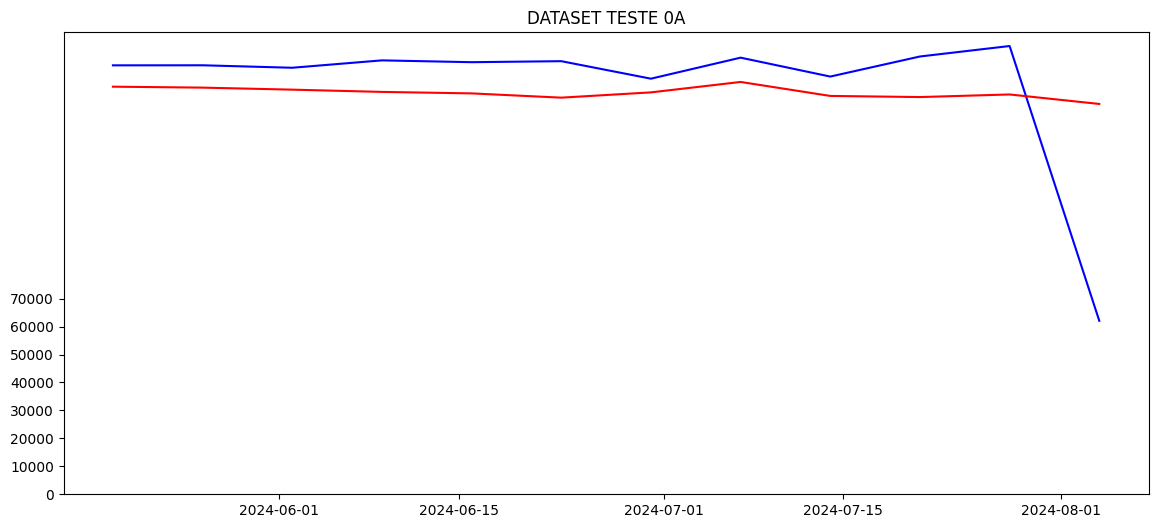

In [26]:
pred_A = model0A.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled_A = scalers[4].inverse_transform(pred_A)
y_pred_rescaled_A = y_pred_rescaled_A.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled_A, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 0A")

# Nome do arquivo incluindo a variável 'name'
file_name = 'prediction_plot_teste_0A.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_avaliacao_teste_0, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

In [27]:
#avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio_avaliacao_teste_0, 'split')

save_function_output(avaliacao_multistep, 
                     duas_unas_validation_rescaled, 
                     y_pred_rescaled_A, 
                     diretorio_avaliacao_teste_0,
                     'split_0A',
                     output_file='avaliacao_teste_0A.txt', 
                     output_dir=diretorio_avaliacao_teste_0)

Output salvo em: Resultados_PSO/pso_du/7_days/avaliacao_testes/teste_0\avaliacao_teste_0A.txt


## **TESTE 00B**
Dataset Duas Unas.

Teste tradicional do modelo PSO otimizado treinado apenas pelo dataset Duas Unas.

In [23]:
### DATASETS PARA TESTE 00 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0B = concatenate_selected_datasets(scaled_datasets, indices)


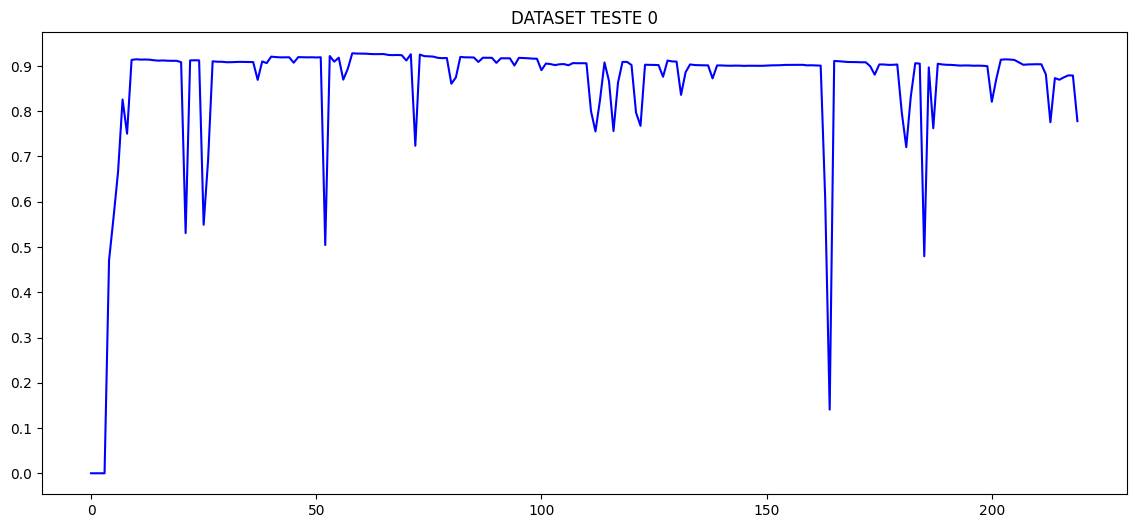

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0B, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 0")
plt.show()

X shape (130, 1)
y shape (130, 90)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: 0.8744 - val_loss: 0.8349
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 0.8283 - val_loss: 0.7969
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.7899 - val_loss: 0.7509
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.7425 - val_loss: 0.6842
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.6702 - val_loss: 0.5721
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5470 - val_loss: 0.3595
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3095 - val_loss: 0.0780
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1301 - val_loss: 0.0473
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1180 - val_loss: 0.0449
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1108 - val_loss: 0.0420
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1046 - val_loss: 0.0679
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━━

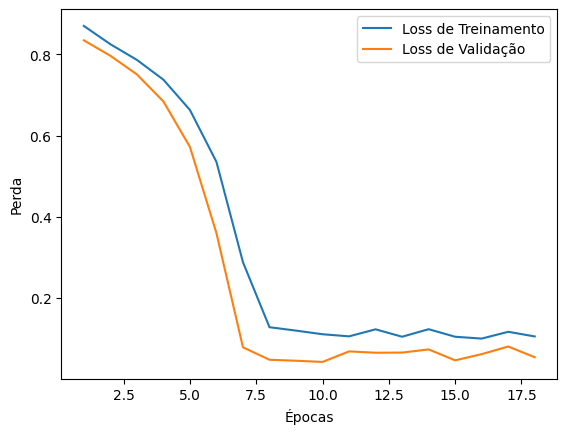

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_0B, y_0B = create_dataset(dataset_test_0B, timesteps, output_steps)
X_0B = X_0B.reshape(X_0B.shape[0], X_0B.shape[1], 1)
X_trainB, X_testB, y_trainB, y_testB = train_test_split(X_0B, y_0B, test_size=0.2, random_state=42)

model0 = Sequential()

for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
    model0.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                    #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                    return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X_0B.shape[1], 1)))

    model0.add(Dropout(config['datasets'][dataset_type_du]['dropout']))

model0.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                    activation=config['datasets'][dataset_type_du]['activation']))

model0.summary()

# Configurar o otimizador
optimizer = config['datasets'][dataset_type_du]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])
else:
    opt = SGD(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])

# Configurar a função de perda
loss_function = config['datasets'][dataset_type_du]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model0.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type_du]['patience'], restore_best_weights=True)

history = model0.fit(X_trainB, y_trainB, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_testB, y_testB), 
                callbacks=[early_stopping])
    
# Ajuste do gráfico para começar em 1
epochs_range = range(1, len(history.history['loss']) + 1)

plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step


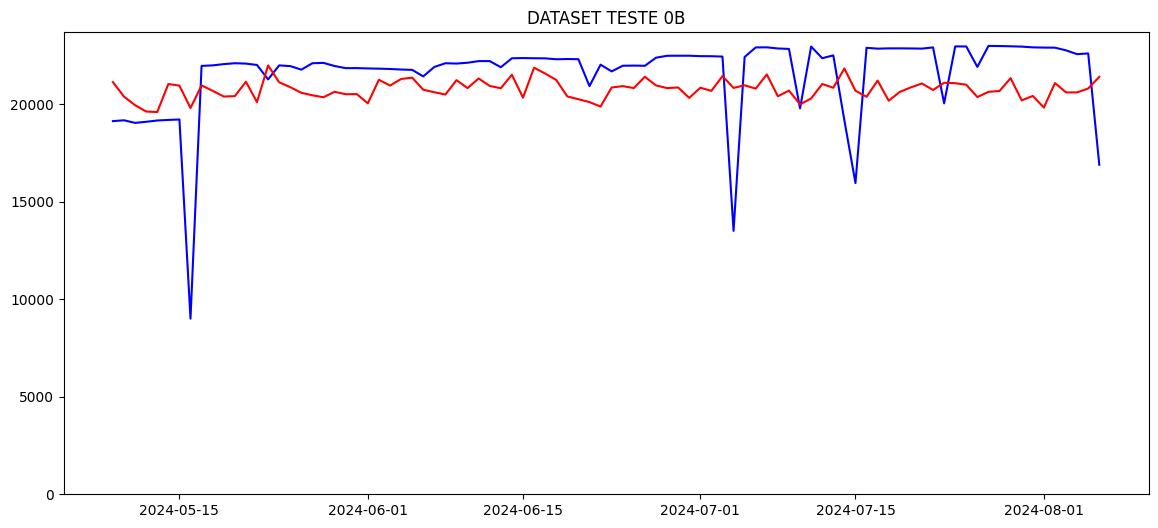

In [28]:
pred_B = model0.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled_B = scalers[4].inverse_transform(pred_B)
y_pred_rescaled_B = y_pred_rescaled_B.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled_B = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled_B, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled_B, label="Predict", color='red')
plt.yticks(np.arange(0,25000,step=5000))
plt.title("DATASET TESTE 0B")

# Nome do arquivo incluindo a variável 'name'
file_name = 'prediction_plot_teste_0B.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_avaliacao_teste_0, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

In [29]:
#avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio_avaliacao_teste_0, 'split')

save_function_output(avaliacao_multistep, 
                     duas_unas_validation_rescaled_B, 
                     y_pred_rescaled_B, 
                     diretorio_avaliacao_teste_0,
                     'split_0B',
                     output_file='avaliacao_teste_0B.txt', 
                     output_dir=diretorio_avaliacao_teste_0)

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_0\avaliacao_teste_0B.txt


## **TESTE 01**
Prata I, II, III e Duas Unas.
Ações a serem testadas:

0. Validar se a técnica de TL que envolve congelamento de camadas é reconhecido e amplamente utilizado;
1. Padronizar cada dataset em separado (Prata I, II, III);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 01 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [1, 2, 3]
dataset_test_1 = concatenate_selected_datasets(scaled_datasets, indices)

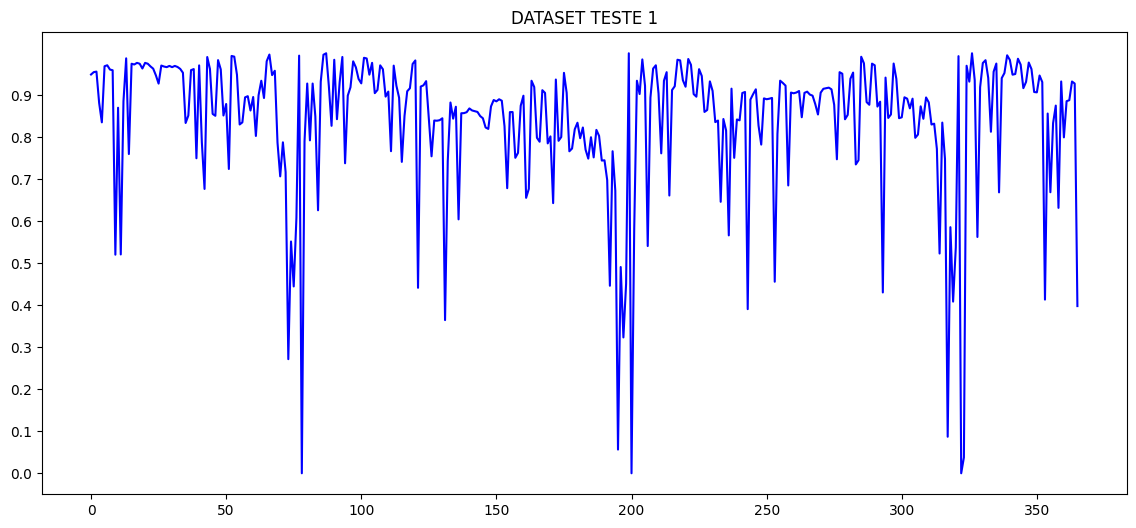

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_1, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_1, y_1 = create_dataset(dataset_test_1, timesteps, output_steps)
X_1 = X_1.reshape(X_1.shape[0], X_1.shape[1], 1)

#model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)

X shape (336, 1)
y shape (336, 30)



Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.8165 - val_loss: 0.8056
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.7779 - val_loss: 0.7617
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7296 - val_loss: 0.6909
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6478 - val_loss: 0.5565
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4869 - val_loss: 0.3138
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2647 - val_loss: 0.1515
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1940 - val_loss: 0.1366
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1895 - val_loss: 0.1334
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1829 - val_loss: 0.1175
Epoch 10/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1716 - val_loss: 0.1431
Epoch 11/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1719 - val_loss: 0.1315
Epoch 12/100000
21/21 ━

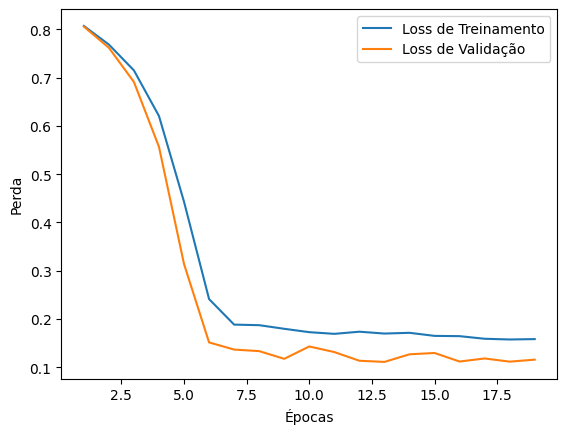

X shape (43, 1)
y shape (43, 30)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.8767 - val_loss: 0.8733
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8755 - val_loss: 0.8703
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8692 - val_loss: 0.8671
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.8672 - val_loss: 0.8641
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8656 - val_loss: 0.8612
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8601 - val_loss: 0.8582
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8613 - val_loss: 0.8552
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8585 - val_loss: 0.8523
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8517 - val_loss: 0.8490
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.8483 - val_loss: 0.8458
Epoch 11/100000
1/1

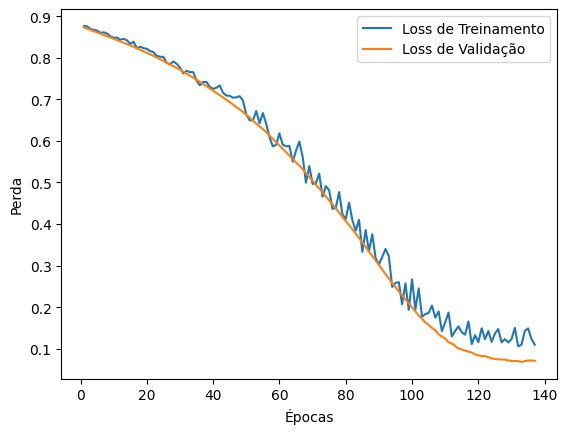

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step


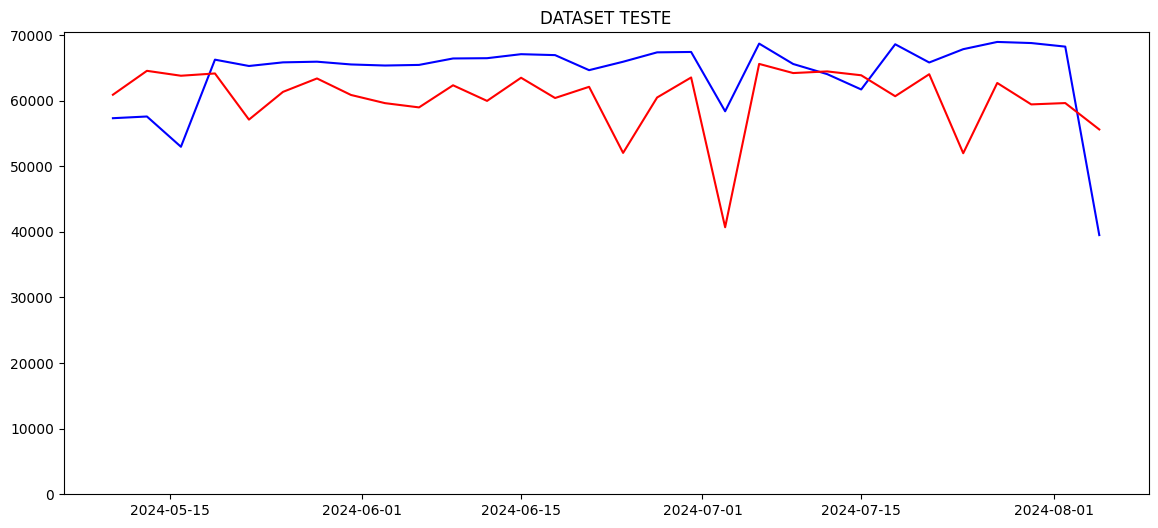

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.1.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - loss: 0.8125 - val_loss: 0.7903
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7770 - val_loss: 0.7519
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7341 - val_loss: 0.6922
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6644 - val_loss: 0.5858
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5441 - val_loss: 0.3944
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3336 - val_loss: 0.1884
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2024 - val_loss: 0.1459
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1969 - val_loss: 0.1416
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1871 - val_loss: 0.1406
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1826 - val_loss: 0.1342
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1749 - val_loss: 0.1293
Epoch 12/100000
18/18 ━━━━━━

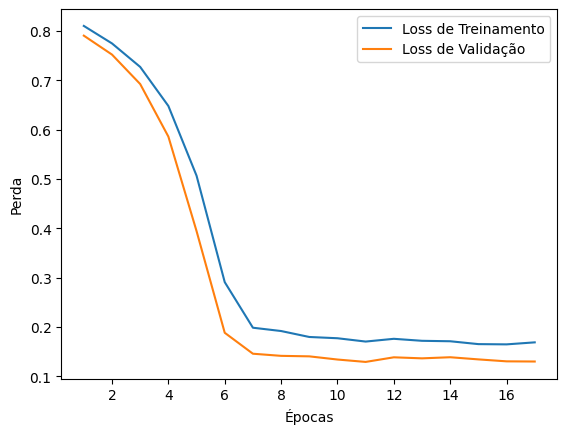

X shape (43, 1)
y shape (43, 30)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.8820 - val_loss: 0.8745
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.8794 - val_loss: 0.8713
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - loss: 0.8755 - val_loss: 0.8680
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.8719 - val_loss: 0.8647
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8690 - val_loss: 0.8616
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8673 - val_loss: 0.8582
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.8647 - val_loss: 0.8551
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.8597 - val_loss: 0.8518
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8566 - val_loss: 0.8484
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.8530 - val_loss: 0.8451
Epoch 11/100000
1/1

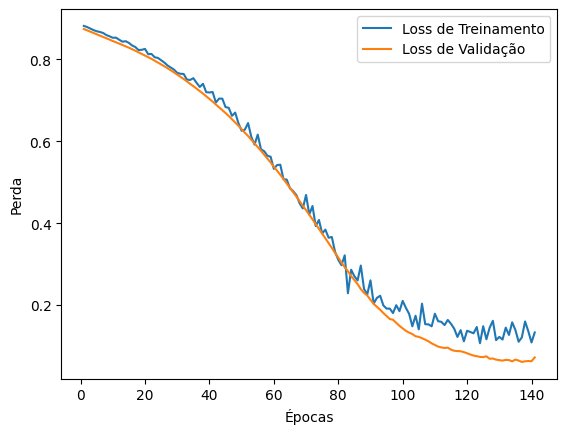

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step


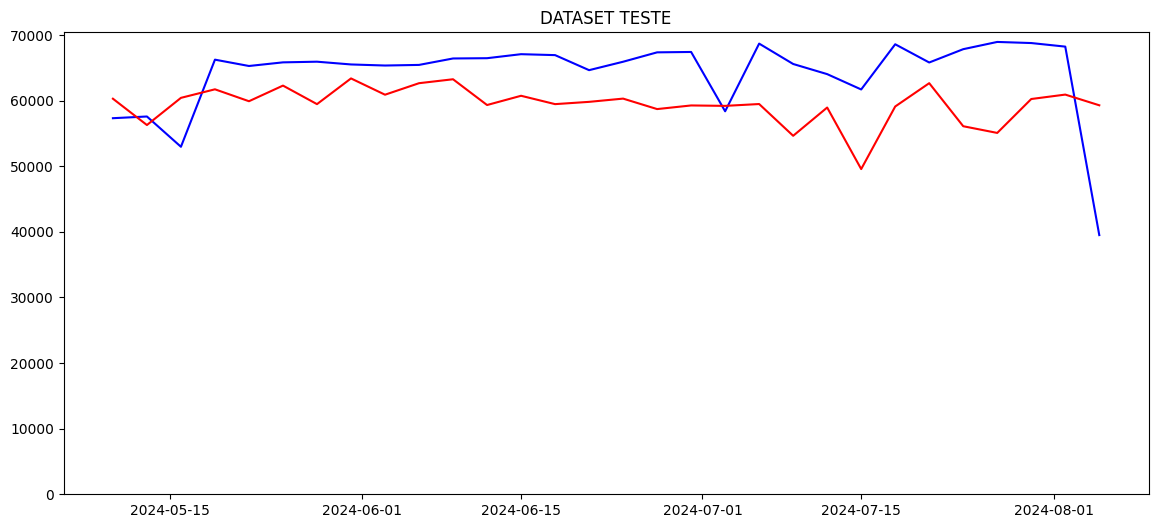

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.2.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - loss: 0.8187 - val_loss: 0.7935
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7879 - val_loss: 0.7625
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7538 - val_loss: 0.7187
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7041 - val_loss: 0.6482
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6227 - val_loss: 0.5283
Epoch 6/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4791 - val_loss: 0.3333
Epoch 7/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2909 - val_loss: 0.1664
Epoch 8/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2062 - val_loss: 0.1447
Epoch 9/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1901 - val_loss: 0.1412
Epoch 10/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1920 - val_loss: 0.1333
Epoch 11/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1879 - val_loss: 0.1322
Epoch 12/100000
16/

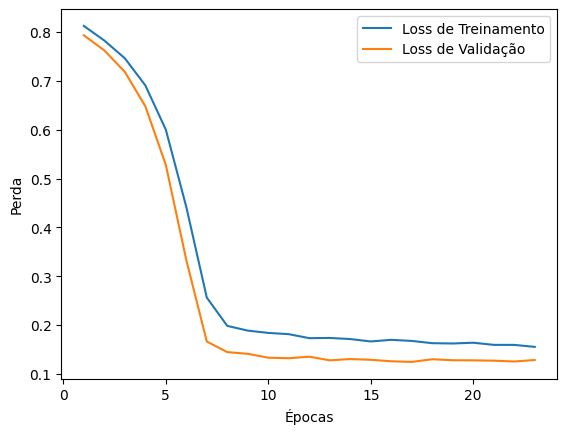

X shape (43, 1)
y shape (43, 30)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.8776 - val_loss: 0.8706
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8744 - val_loss: 0.8664
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.8703 - val_loss: 0.8620
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.8669 - val_loss: 0.8581
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.8635 - val_loss: 0.8543
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.8588 - val_loss: 0.8505
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8534 - val_loss: 0.8466
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8526 - val_loss: 0.8428
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.8458 - val_loss: 0.8389
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8444 - val_loss: 0.8352
Epoch 11/100000
1/1

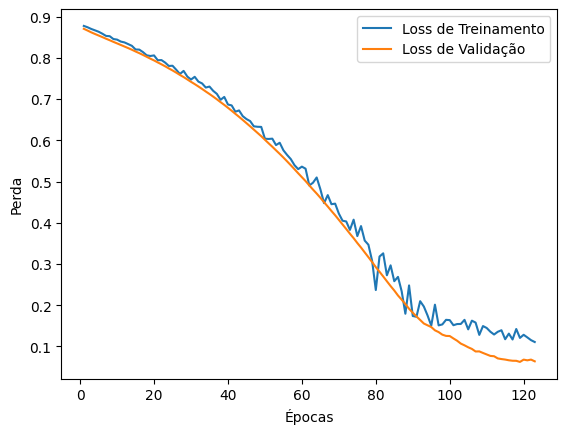

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 694ms/step


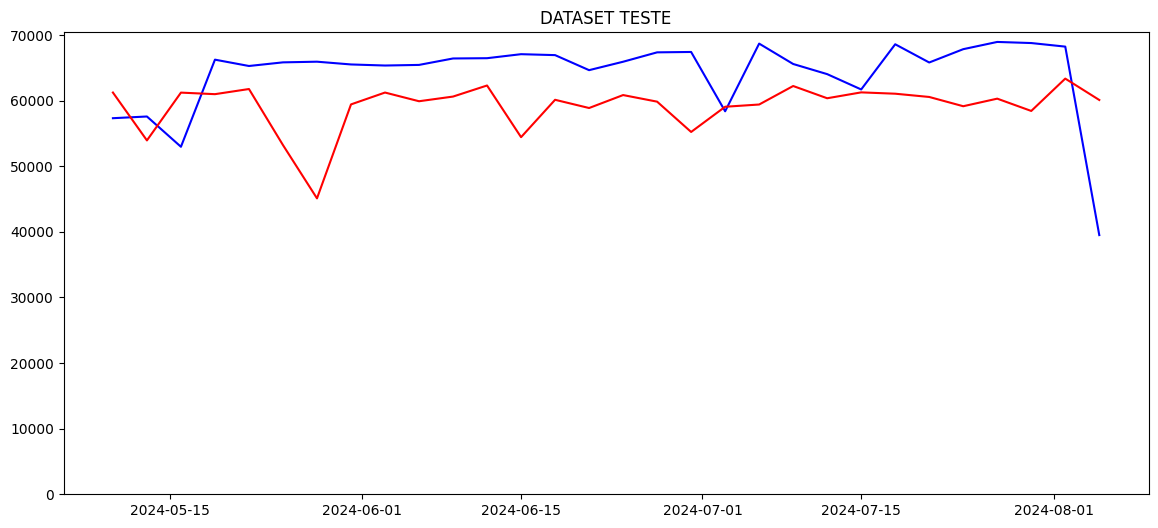

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.30000000000000004.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.8202 - val_loss: 0.8015
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7923 - val_loss: 0.7750
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7640 - val_loss: 0.7405
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7261 - val_loss: 0.6892
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6663 - val_loss: 0.6085
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5707 - val_loss: 0.4790
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4295 - val_loss: 0.2949
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2669 - val_loss: 0.1697
Epoch 9/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1953 - val_loss: 0.1430
Epoch 10/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1882 - val_loss: 0.1285
Epoch 11/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1791 - val_loss: 0.1264
Epoch 12/100000
14/

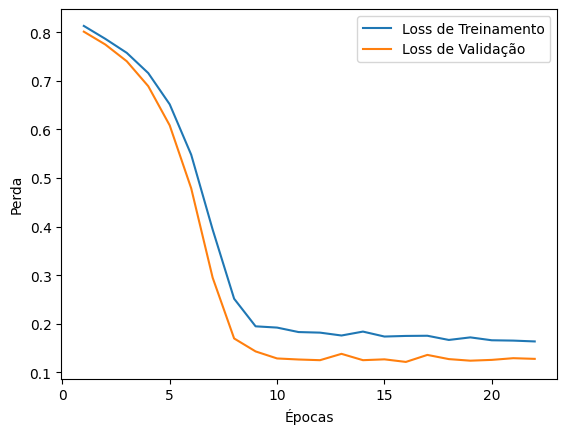

X shape (43, 1)
y shape (43, 30)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.8767 - val_loss: 0.8691
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8701 - val_loss: 0.8616
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.8631 - val_loss: 0.8545
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8557 - val_loss: 0.8471
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8507 - val_loss: 0.8400
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8413 - val_loss: 0.8327
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8376 - val_loss: 0.8252
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8266 - val_loss: 0.8180
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.8198 - val_loss: 0.8102
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8153 - val_loss: 0.8019
Epoch 11/100000
2/2 ━━━━━━━━

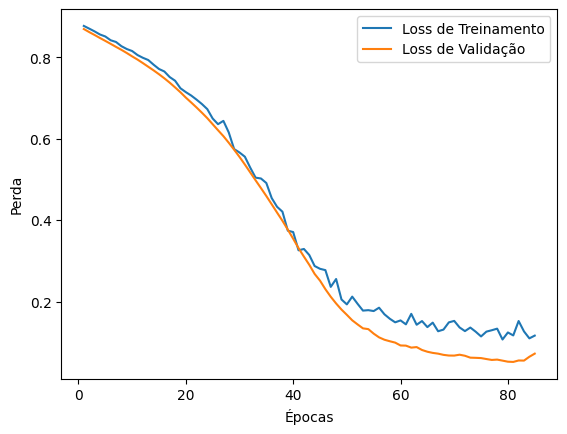

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step


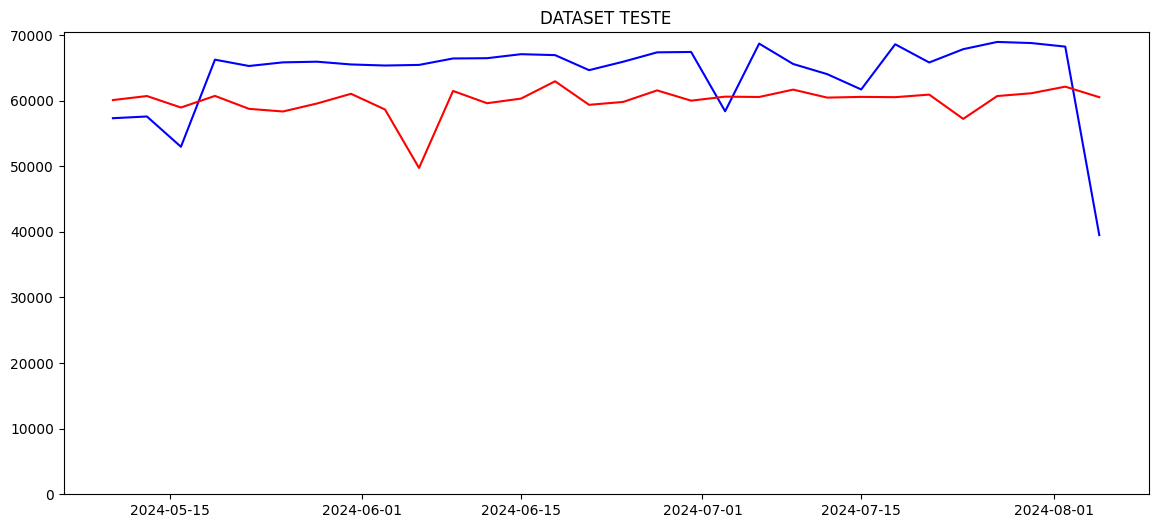

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.4.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.8188 - val_loss: 0.8031
Epoch 2/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7934 - val_loss: 0.7803
Epoch 3/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7704 - val_loss: 0.7525
Epoch 4/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7407 - val_loss: 0.7141
Epoch 5/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6995 - val_loss: 0.6593
Epoch 6/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6374 - val_loss: 0.5743
Epoch 7/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5474 - val_loss: 0.4525
Epoch 8/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4231 - val_loss: 0.2935
Epoch 9/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2760 - val_loss: 0.1765
Epoch 10/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2039 - val_loss: 0.1513
Epoch 11/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1965 - val_loss: 0.1354
Epoch 12/100000
12/

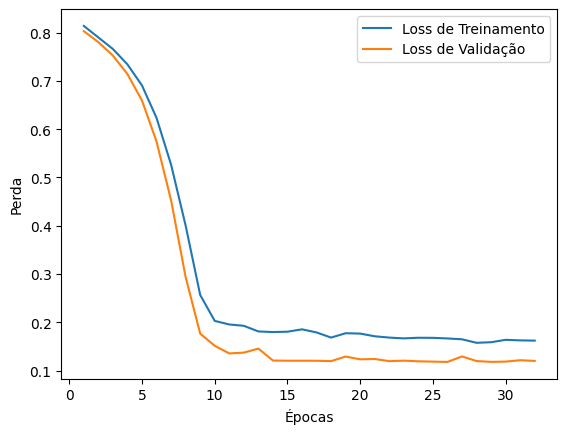

X shape (43, 1)
y shape (43, 30)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 0.8720 - val_loss: 0.8665
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8641 - val_loss: 0.8588
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.8559 - val_loss: 0.8512
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.8508 - val_loss: 0.8435
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8408 - val_loss: 0.8352
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.8332 - val_loss: 0.8271
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.8284 - val_loss: 0.8189
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.8195 - val_loss: 0.8105
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.8084 - val_loss: 0.8016
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.8031 - val_loss: 0.7924
Epoch 11/100000
2/2 ━━━━━━

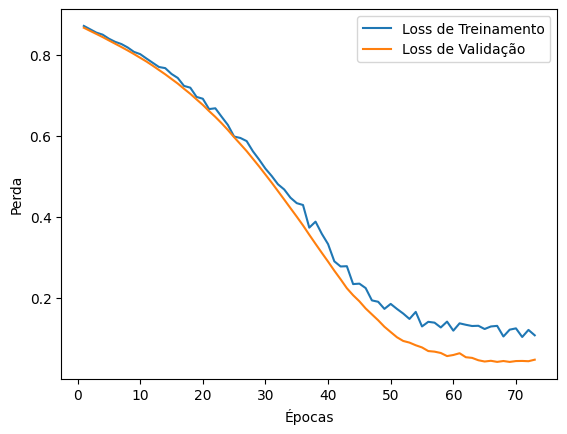

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step


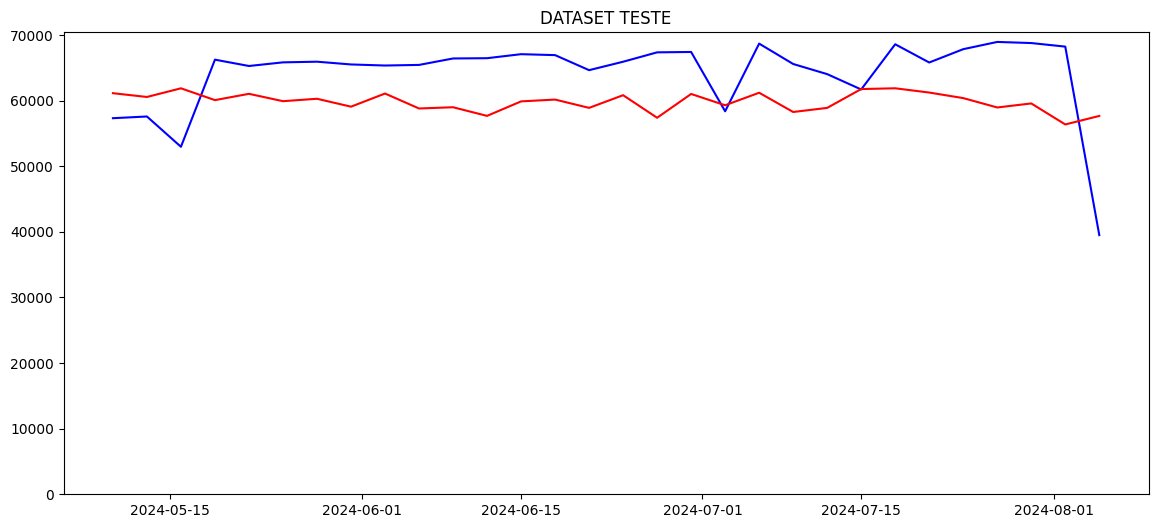

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.5.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - loss: 0.8234 - val_loss: 0.8086
Epoch 2/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8044 - val_loss: 0.7931
Epoch 3/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7889 - val_loss: 0.7764
Epoch 4/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7711 - val_loss: 0.7565
Epoch 5/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7504 - val_loss: 0.7324
Epoch 6/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7272 - val_loss: 0.7021
Epoch 7/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6924 - val_loss: 0.6617
Epoch 8/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6497 - val_loss: 0.6080
Epoch 9/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5966 - val_loss: 0.5363
Epoch 10/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5150 - val_loss: 0.4403
Epoch 11/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4150 - val_loss: 0.3228
Epoch 12/100000
9/9 ━━━━━━━━━━━━━━━━━━━

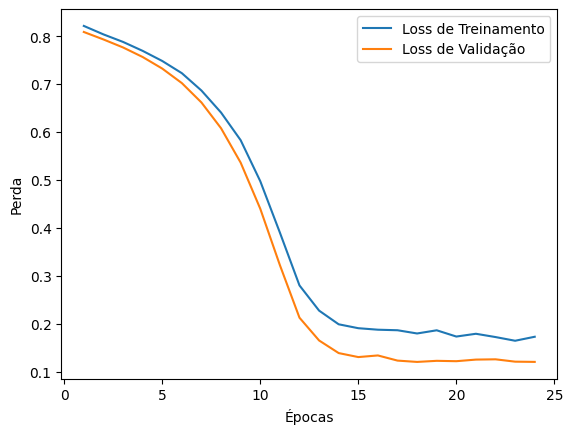

X shape (43, 1)
y shape (43, 30)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 0.8773 - val_loss: 0.8705
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step - loss: 0.8700 - val_loss: 0.8638
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.8640 - val_loss: 0.8570
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8580 - val_loss: 0.8501
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8497 - val_loss: 0.8430
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8446 - val_loss: 0.8360
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8355 - val_loss: 0.8283
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8294 - val_loss: 0.8205
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8242 - val_loss: 0.8124
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.8131 - val_loss: 0.8036
Epoch 11/100000
2/2 ━━━━━━━

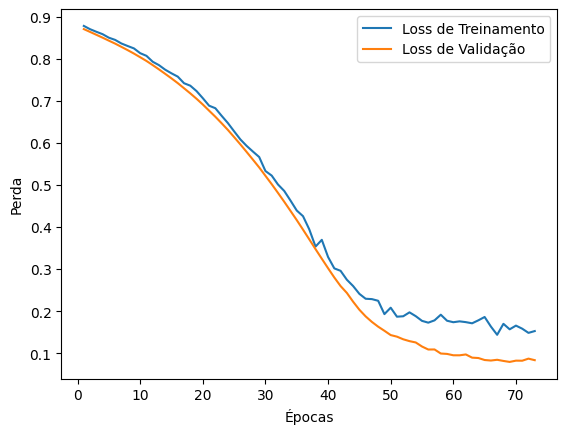

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step


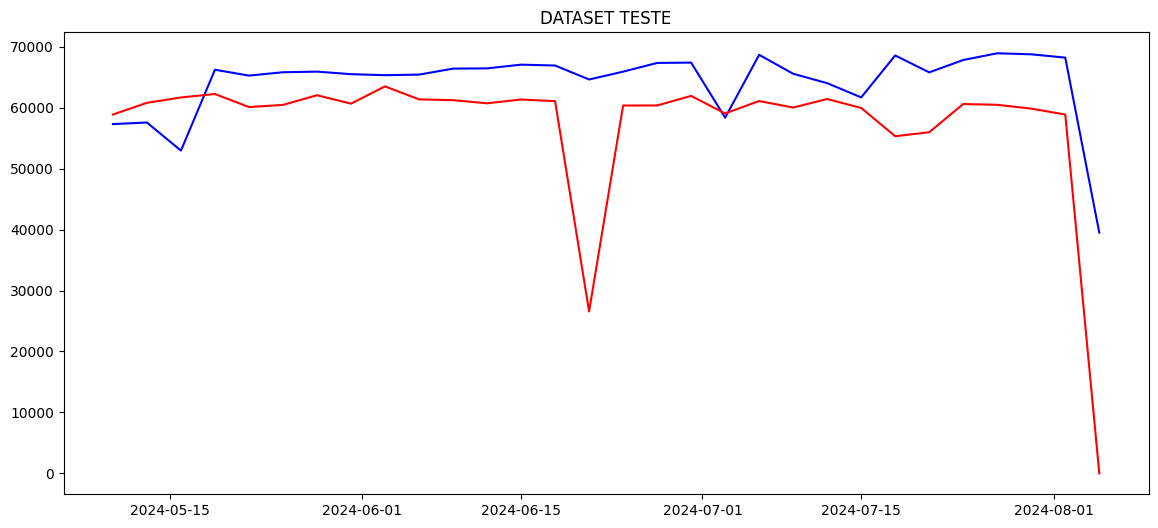

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.6.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - loss: 0.8316 - val_loss: 0.8127
Epoch 2/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.8152 - val_loss: 0.8001
Epoch 3/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8028 - val_loss: 0.7877
Epoch 4/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7903 - val_loss: 0.7742
Epoch 5/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7747 - val_loss: 0.7586
Epoch 6/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7586 - val_loss: 0.7404
Epoch 7/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7398 - val_loss: 0.7189
Epoch 8/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7193 - val_loss: 0.6927
Epoch 9/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6913 - val_loss: 0.6602
Epoch 10/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6583 - val_loss: 0.6189
Epoch 11/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6072 - val_loss: 0.5657
Epoch 12/100000
7/7 ━━━━━━━━━━━━━━━━━━━━

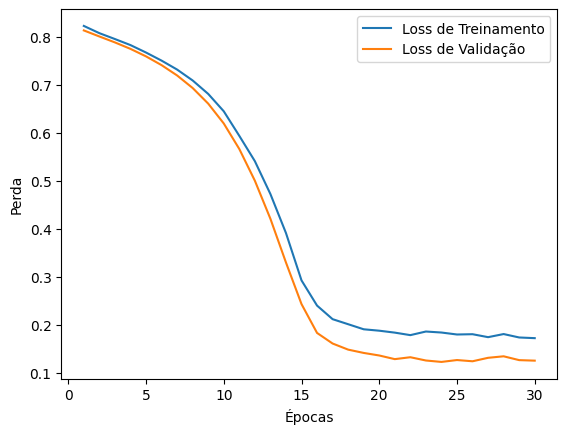

X shape (43, 1)
y shape (43, 30)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 968ms/step - loss: 0.8750 - val_loss: 0.8699
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8678 - val_loss: 0.8625
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.8616 - val_loss: 0.8555
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8556 - val_loss: 0.8490
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8479 - val_loss: 0.8423
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.8431 - val_loss: 0.8358
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8348 - val_loss: 0.8284
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.8292 - val_loss: 0.8209
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.8216 - val_loss: 0.8127
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8129 - val_loss: 0.8042
Epoch 11/100000
2/2 ━━━━━

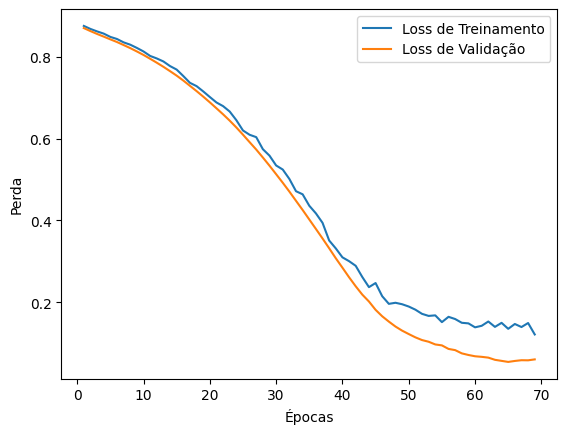

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step


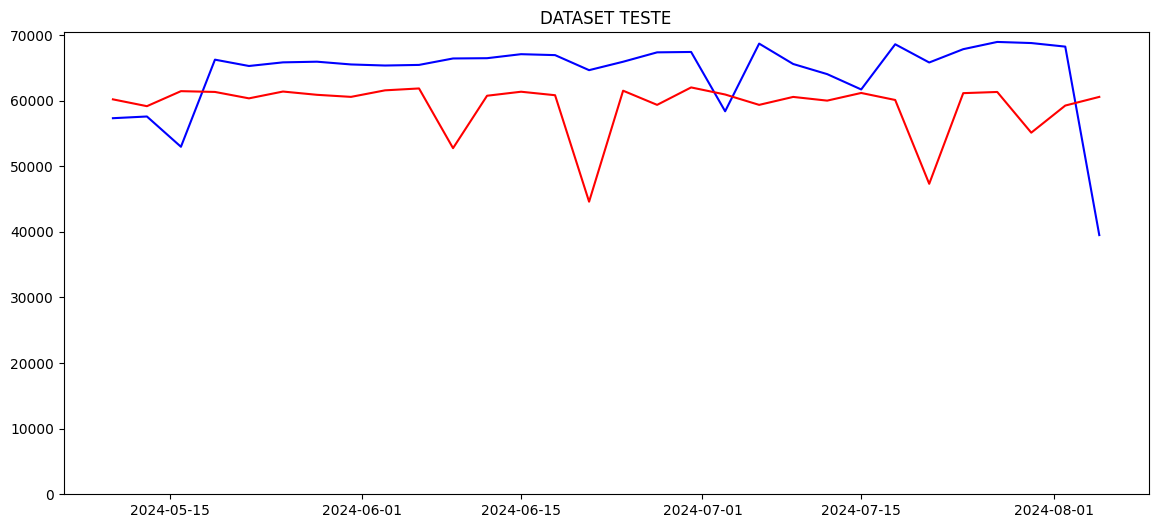

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.7.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - loss: 0.8358 - val_loss: 0.8191
Epoch 2/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8242 - val_loss: 0.8104
Epoch 3/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.8157 - val_loss: 0.8026
Epoch 4/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8074 - val_loss: 0.7946
Epoch 5/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8001 - val_loss: 0.7864
Epoch 6/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7918 - val_loss: 0.7777
Epoch 7/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7824 - val_loss: 0.7681
Epoch 8/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7726 - val_loss: 0.7575
Epoch 9/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7611 - val_loss: 0.7457
Epoch 10/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7489 - val_loss: 0.7326
Epoch 11/100000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7368 - val_loss: 0.7178
Epoch 12/100000
5/5 ━━━━━━━━━━━━━━━━━━━

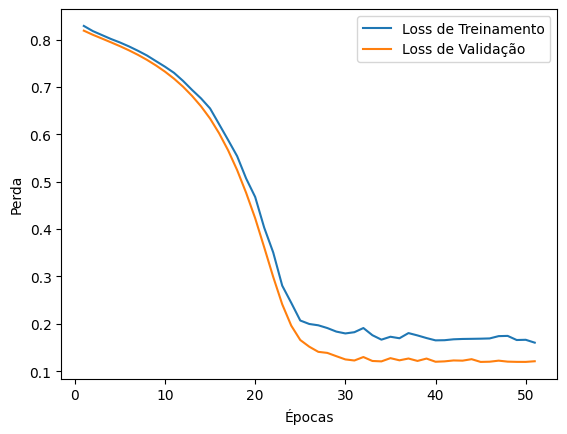

X shape (43, 1)
y shape (43, 30)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_45 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 490ms/step - loss: 0.8762 - val_loss: 0.8650
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8689 - val_loss: 0.8558
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8595 - val_loss: 0.8465
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.8492 - val_loss: 0.8364
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8413 - val_loss: 0.8270
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8320 - val_loss: 0.8171
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8215 - val_loss: 0.8070
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8106 - val_loss: 0.7957
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8006 - val_loss: 0.7832
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7867 - val_loss: 0.7699
Epoch 11/100000
3/3 ━━━━━

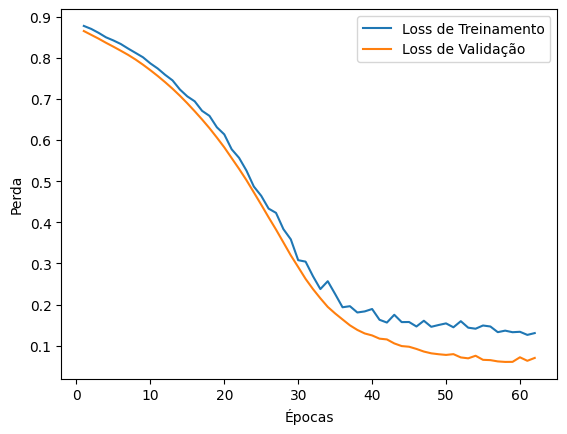

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step


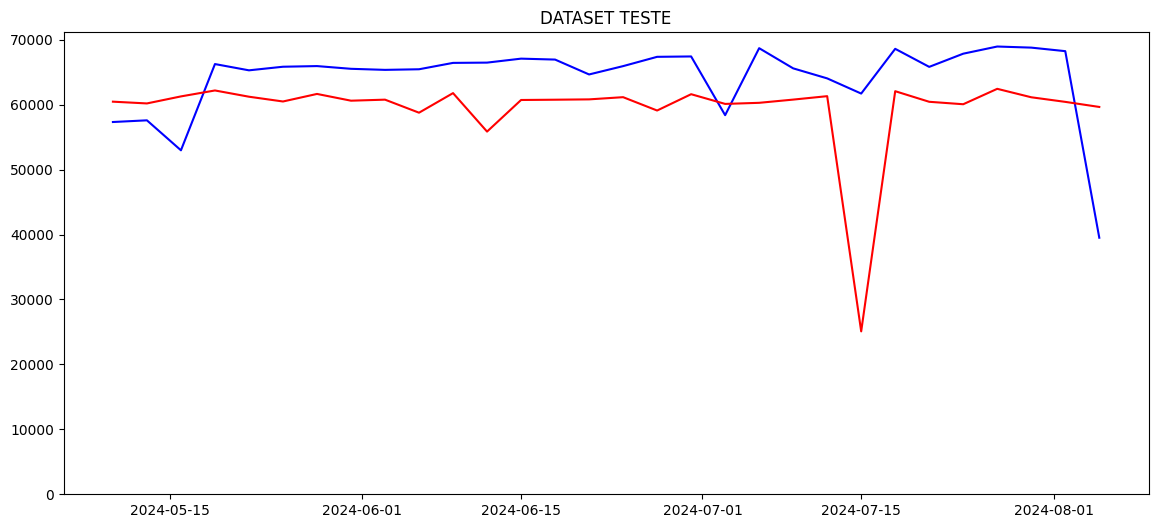

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.7999999999999999.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 876ms/step - loss: 0.7971 - val_loss: 0.8241
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.7882 - val_loss: 0.8177
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.7825 - val_loss: 0.8124
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.7770 - val_loss: 0.8074
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.7720 - val_loss: 0.8025
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.7674 - val_loss: 0.7977
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.7623 - val_loss: 0.7928
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.7579 - val_loss: 0.7877
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.7530 - val_loss: 0.7826
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7482 - val_loss: 0.7773
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.7428 - val_loss: 0.7716
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━

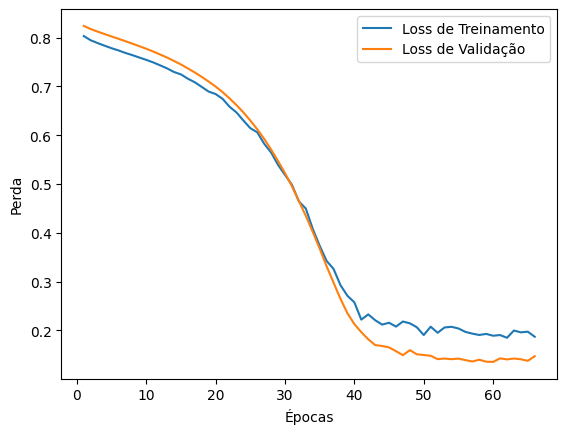

X shape (43, 1)
y shape (43, 30)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_51 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.8702 - val_loss: 0.8523
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8603 - val_loss: 0.8426
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8501 - val_loss: 0.8325
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8400 - val_loss: 0.8222
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8309 - val_loss: 0.8116
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.8180 - val_loss: 0.8005
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8046 - val_loss: 0.7879
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7950 - val_loss: 0.7749
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7789 - val_loss: 0.7599
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7631 - val_loss: 0.7446
Epoch 11/100000
3/3 ━━━━━━━

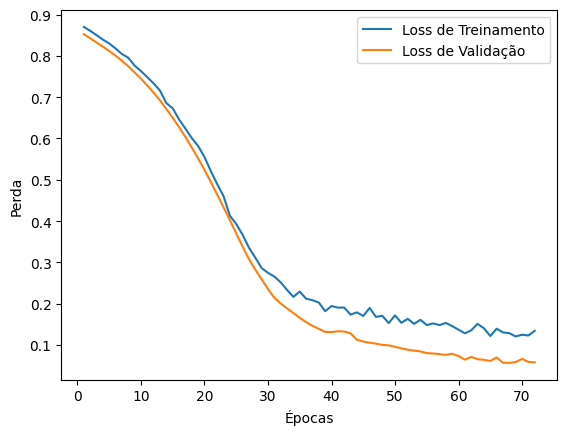

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step


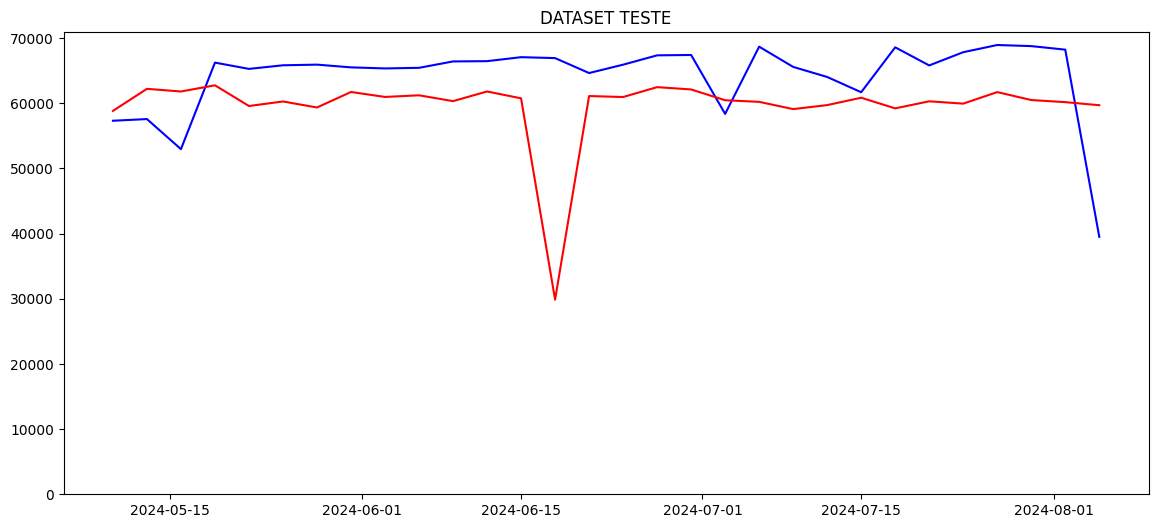

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split_0.8999999999999999.txt


In [26]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model1 = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, k=k, tt_rate=0)
#     transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, str(k))
    
# Treinamento com train-test split
tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    print("\nTraining with train-test split")
    validation_method = 'split'
    model1 = create_and_train_model(config, dataset_type_du, X_1, y_1, validation_method, None, tt_rate)
    transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, tt_rate)



# # Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model3 = train_model(X_3, y_3, validation_method, k, tt_rate=0)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# # Treinamento com train-test split
# tt_rate = 0
# for k in range(1,10):
#     tt_rate += 0.10
#     print("\nTraining with train-test split")
#     validation_method = 'split'
#     model3 = train_model(X_3, y_3, validation_method, None, tt_rate)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, tt_rate)

In [27]:
# #model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)
# for k in range(2,9):
#     model1 = create_model(config, dataset_type_du, X_1, y_1, 'k-fold', k)
#     results(model1, duas_unas_validation_scaled, validation_method, diretorio_avaliacao_teste_1, k)

# model1 = create_model(config, dataset_type_du, X_1, y_1, 'split', 0)
# results(model1, duas_unas_validation_scaled, validation_method, diretorio_avaliacao_teste_1, 'split')

In [28]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento1 = model1.get_weights()
# pesos_LSTM1_t1 = model1.layers[0].get_weights()
# pesos_LSTM2_t1 = model1.layers[2].get_weights()
# pesos_LSTM3_t1 = model1.layers[4].get_weights()
# pesos_DENSE_t1 = model1.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz'), *pesos_LSTM1_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz'), *pesos_LSTM2_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz'), *pesos_LSTM3_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_DENSE_t1_{validation_method}.npz'), *pesos_DENSE_t1)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_modelo_t1_{validation_method}.npz'), *pesos_treinamento1)

# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz'))
# pesos_carregados_LSTM2_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz'))
# pesos_carregados_LSTM3_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz'))

In [29]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model1_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model1_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model1_ft.add(Dropout(0.3))

# model1_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model1_ft.summary()

In [30]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz')
# caminho_LSTM2_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz')
# caminho_LSTM3_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz')

# carregar_e_aplicar_pesos(model1_ft, caminho_LSTM1_t1, caminho_LSTM2_t1, caminho_LSTM3_t1)

In [31]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t1[0], model1_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t1[1], model1_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t1[2], model1_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t1[0], model1_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t1[1], model1_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t1[2], model1_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t1[0], model1_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t1[1], model1_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t1[2], model1_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)


In [32]:
# congelar_camadas(model1_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model1_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [33]:
# descongelar_camadas(model1_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model1_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [34]:
# pred = model1_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 1")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_1, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [35]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_1)

## **TESTE 02**

Prata I, II, III e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 02 ###

indices = [1, 2, 3, 4]
dataset_test_2 = concatenate_selected_datasets(scaled_datasets, indices)

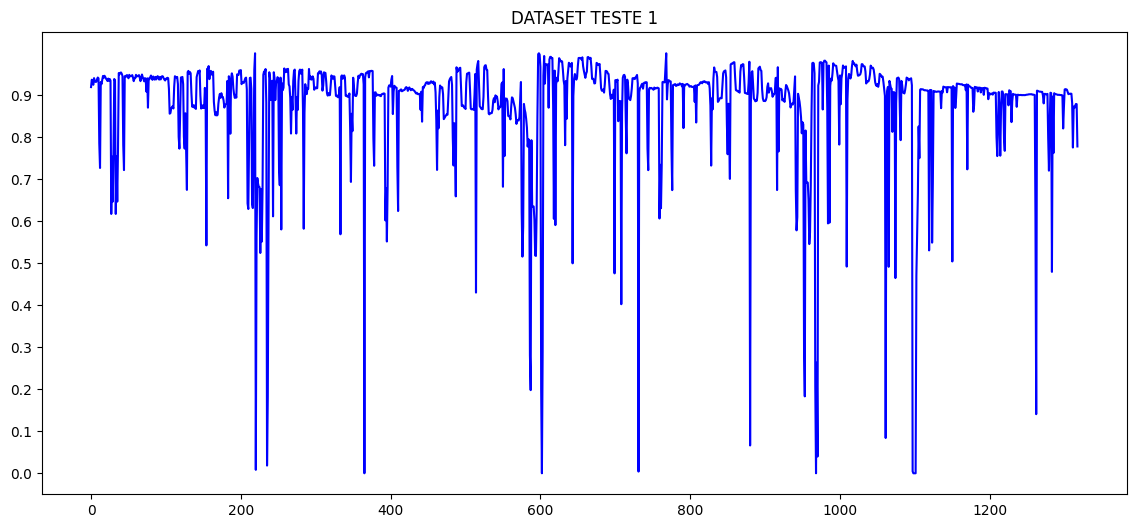

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_2, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_2, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

X shape (1228, 1)
y shape (1228, 90)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - loss: 0.7538 - val_loss: 0.1244
Epoch 2/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1383 - val_loss: 0.1571
Epoch 3/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1333 - val_loss: 0.1107
Epoch 4/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1214 - val_loss: 0.0943
Epoch 5/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1146 - val_loss: 0.1447
Epoch 6/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1181 - val_loss: 0.1250
Epoch 7/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1109 - val_loss: 0.0994
Epoch 8/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1045 - val_loss: 0.1110
Epoch 9/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1030 - val_loss: 0.1139
Epoch 10/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1037 - val_loss: 0.1216
Epoch 11/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1002 - val_loss: 0.1126
Epoch 12/100000
25

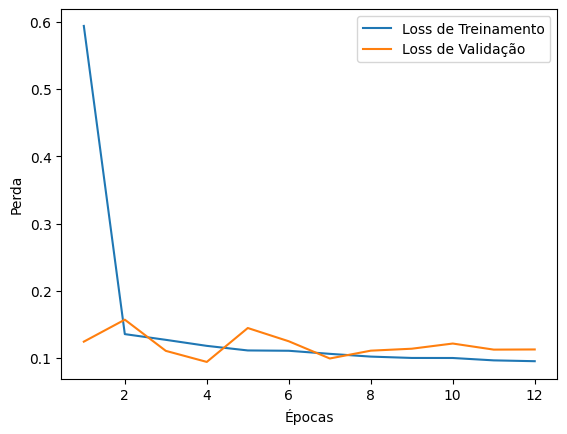

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step


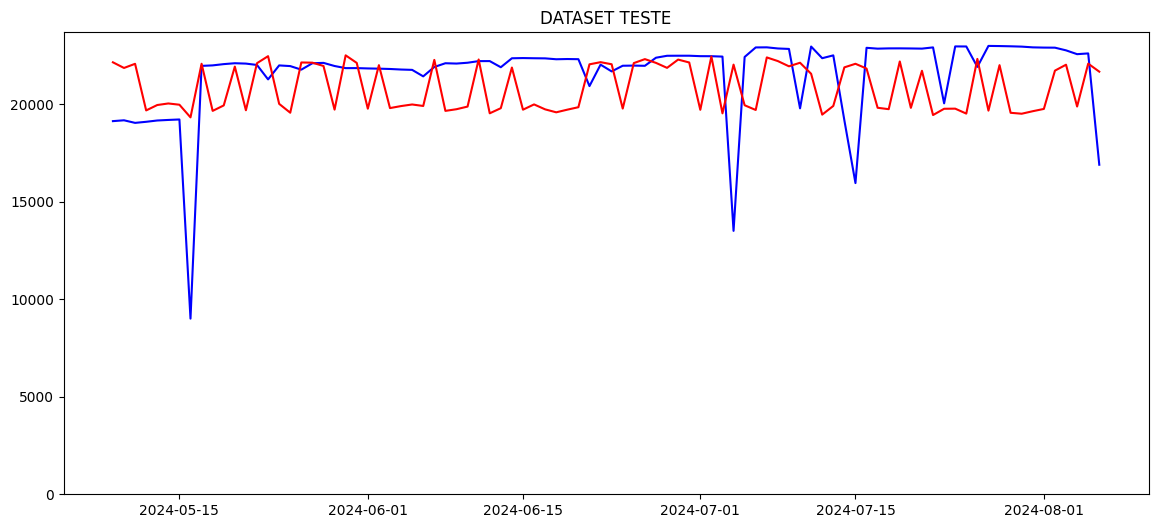

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.1.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - loss: 0.7800 - val_loss: 0.0977
Epoch 2/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1354 - val_loss: 0.1289
Epoch 3/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1334 - val_loss: 0.1044
Epoch 4/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1245 - val_loss: 0.0796
Epoch 5/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1116 - val_loss: 0.0892
Epoch 6/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1140 - val_loss: 0.0802
Epoch 7/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1048 - val_loss: 0.0854
Epoch 8/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1027 - val_loss: 0.0757
Epoch 9/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0995 - val_loss: 0.0764
Epoch 10/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0981 - val_loss: 0.0769
Epoch 11/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0957 - val_loss: 0.0759
Epoch 12/100000
22

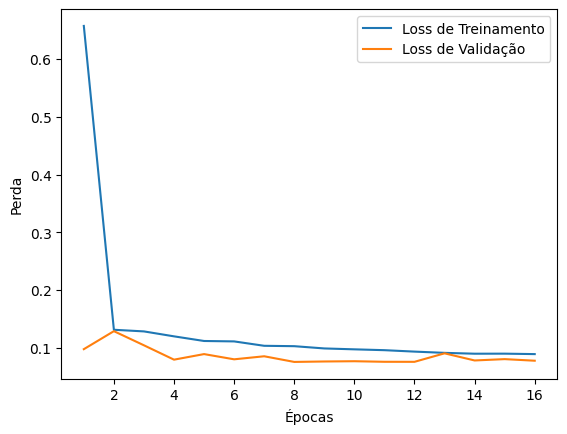

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step


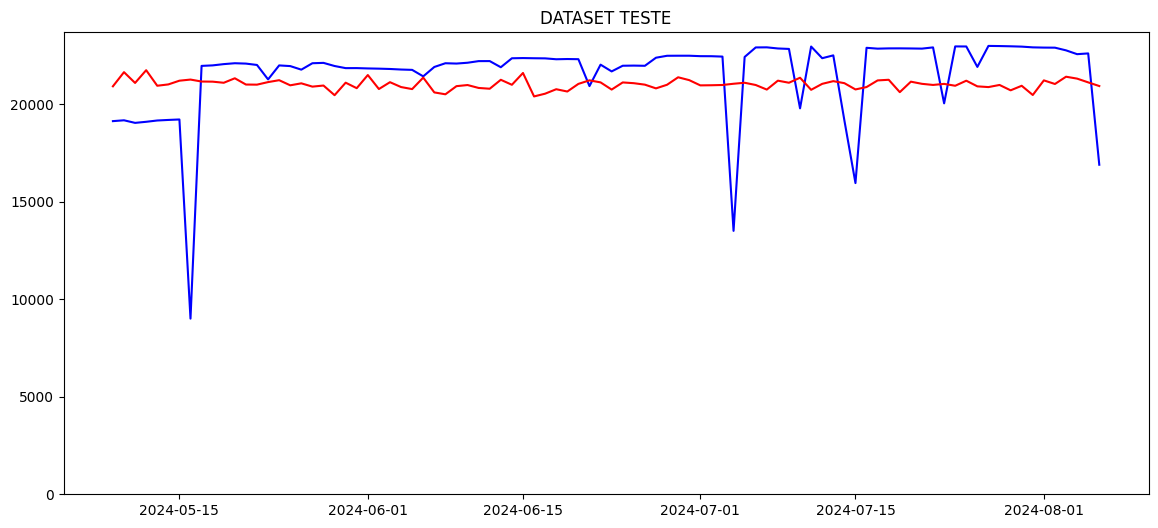

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.7980 - val_loss: 0.2996
Epoch 2/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1789 - val_loss: 0.1161
Epoch 3/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1315 - val_loss: 0.0779
Epoch 4/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1248 - val_loss: 0.1149
Epoch 5/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1206 - val_loss: 0.0866
Epoch 6/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1140 - val_loss: 0.0759
Epoch 7/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1078 - val_loss: 0.0765
Epoch 8/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1051 - val_loss: 0.0779
Epoch 9/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1030 - val_loss: 0.0833
Epoch 10/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1015 - val_loss: 0.0805
Epoch 11/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1000 - val_loss: 0.0776
Epoch 12/100000
1

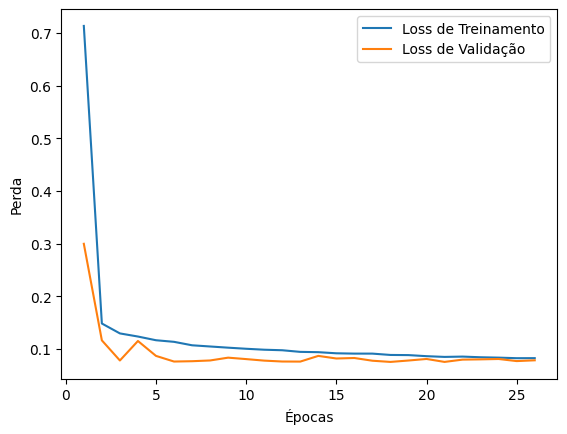

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step


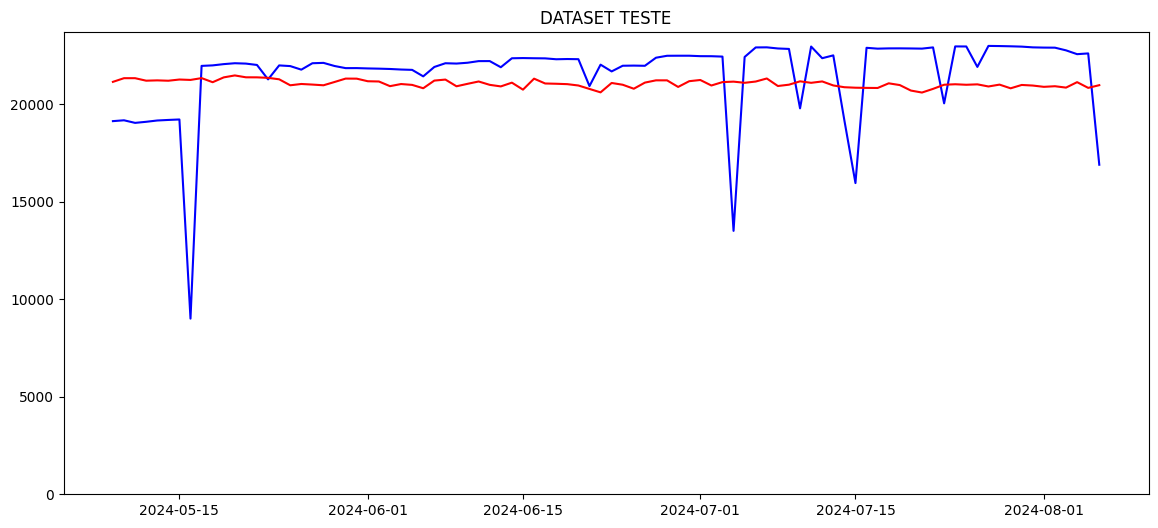

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.30000000000000004.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.8123 - val_loss: 0.4865
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2725 - val_loss: 0.1204
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1343 - val_loss: 0.0777
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1268 - val_loss: 0.1085
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1189 - val_loss: 0.0771
Epoch 6/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1171 - val_loss: 0.0783
Epoch 7/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1144 - val_loss: 0.0796
Epoch 8/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1083 - val_loss: 0.0816
Epoch 9/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1037 - val_loss: 0.0800
Epoch 10/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1043 - val_loss: 0.0760
Epoch 11/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1044 - val_loss: 0.0904
Epoch 12/100000
16

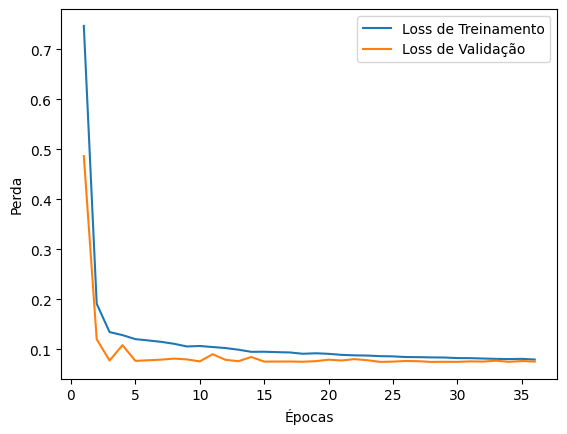

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step


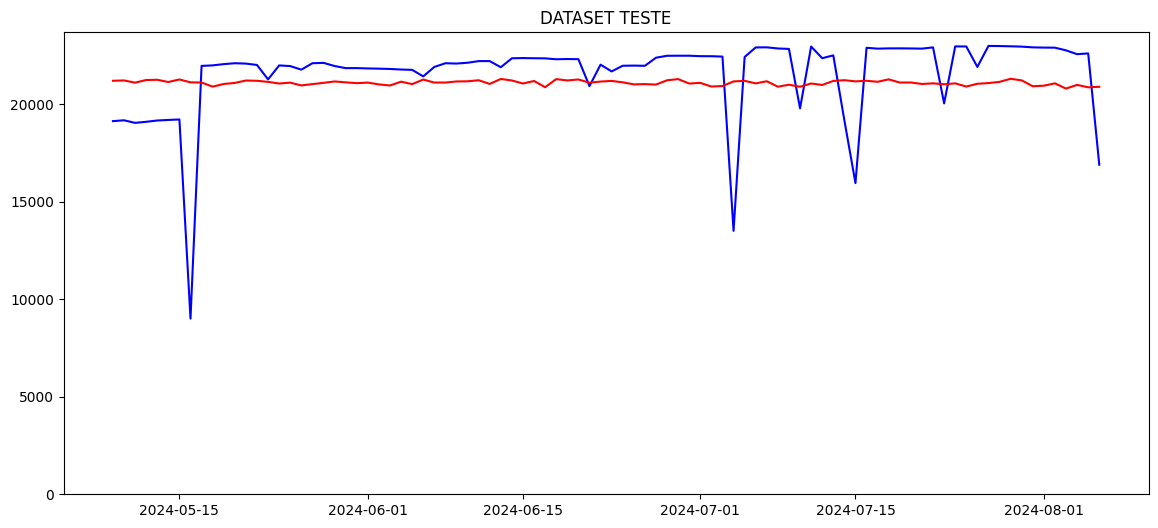

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.8202 - val_loss: 0.6160
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4172 - val_loss: 0.1152
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1398 - val_loss: 0.0785
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1315 - val_loss: 0.0813
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1225 - val_loss: 0.0837
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1217 - val_loss: 0.0771
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1165 - val_loss: 0.0916
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1164 - val_loss: 0.0765
Epoch 9/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1138 - val_loss: 0.0799
Epoch 10/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1074 - val_loss: 0.0759
Epoch 11/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1111 - val_loss: 0.0790
Epoch 12/100000
1

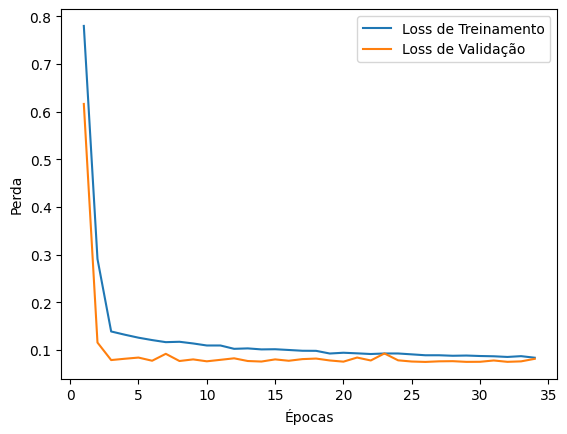

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step


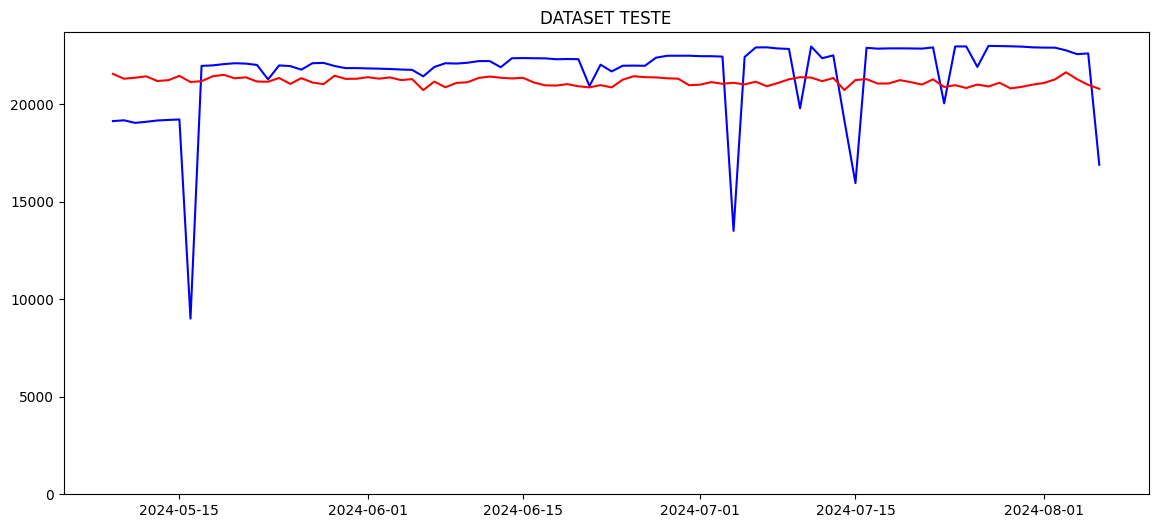

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - loss: 0.8329 - val_loss: 0.7056
Epoch 2/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.6001 - val_loss: 0.1030
Epoch 3/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1380 - val_loss: 0.0823
Epoch 4/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1297 - val_loss: 0.1568
Epoch 5/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1350 - val_loss: 0.0849
Epoch 6/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1283 - val_loss: 0.1276
Epoch 7/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1229 - val_loss: 0.0855
Epoch 8/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1209 - val_loss: 0.0975
Epoch 9/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1149 - val_loss: 0.0988
Epoch 10/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1164 - val_loss: 0.0983
Epoch 11/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1104 - val_loss: 0.0791
Epoch 12/100000
1

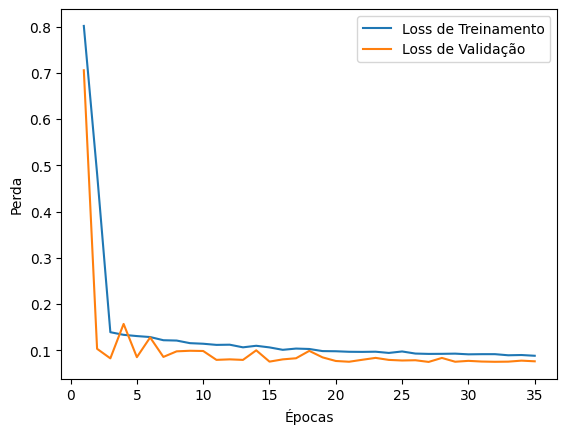

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step


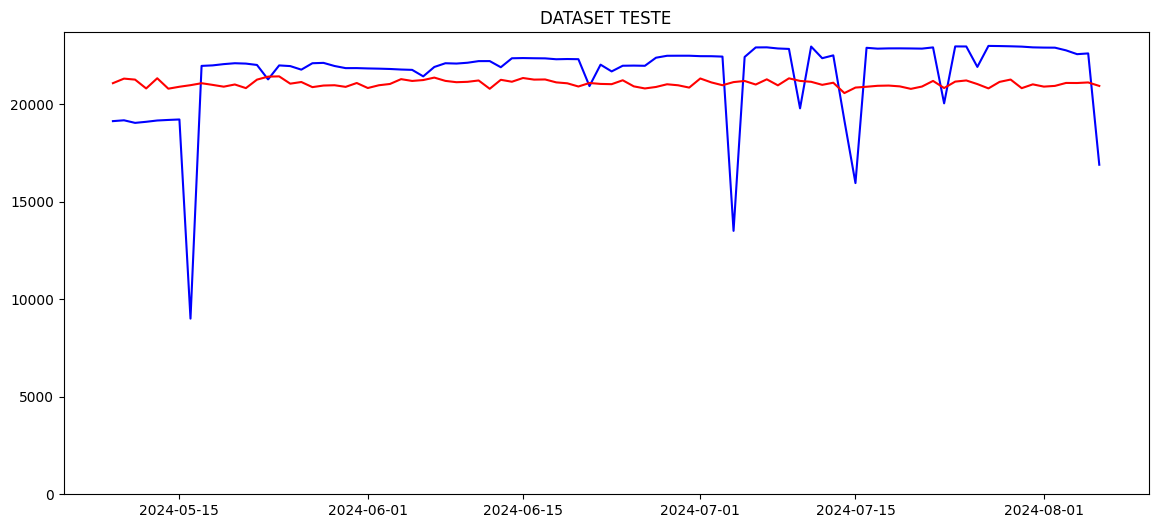

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - loss: 0.8428 - val_loss: 0.7634
Epoch 2/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.7222 - val_loss: 0.5170
Epoch 3/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3693 - val_loss: 0.0813
Epoch 4/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1357 - val_loss: 0.0779
Epoch 5/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1361 - val_loss: 0.0888
Epoch 6/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1460 - val_loss: 0.1147
Epoch 7/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1317 - val_loss: 0.0754
Epoch 8/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1239 - val_loss: 0.0794
Epoch 9/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1215 - val_loss: 0.0760
Epoch 10/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1163 - val_loss: 0.0932
Epoch 11/100000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1219 - val_loss: 0.0882
Epoch 12/100000
8/8 ━━━━━━━━━━━━━━━━━━

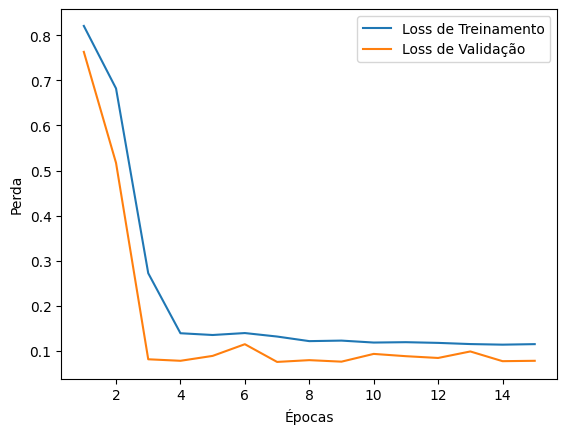

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step


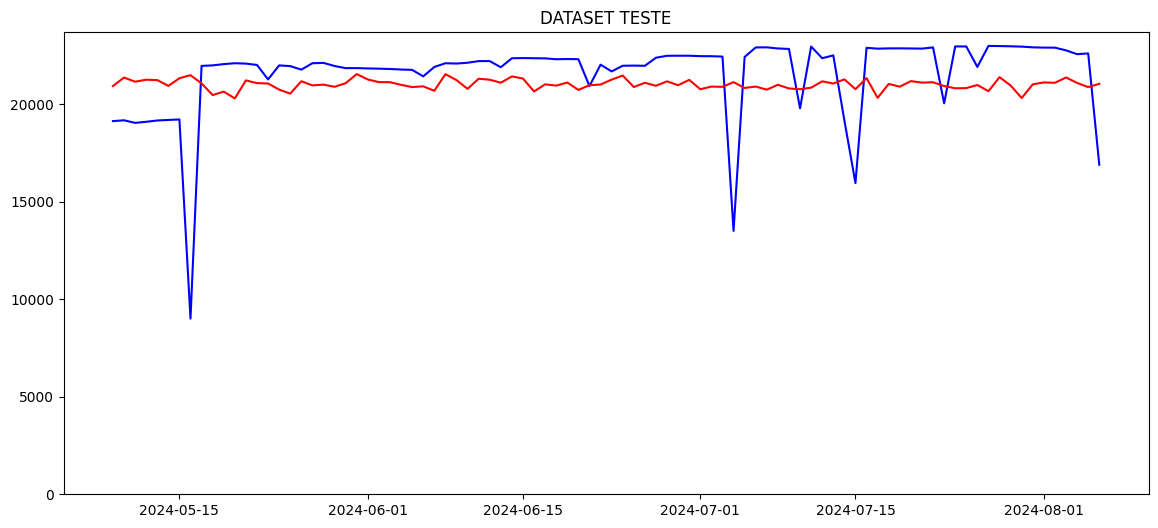

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - loss: 0.8466 - val_loss: 0.7899
Epoch 2/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7649 - val_loss: 0.6781
Epoch 3/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.6268 - val_loss: 0.3520
Epoch 4/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2606 - val_loss: 0.1317
Epoch 5/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1447 - val_loss: 0.1011
Epoch 6/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1418 - val_loss: 0.1101
Epoch 7/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1339 - val_loss: 0.0850
Epoch 8/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1382 - val_loss: 0.1055
Epoch 9/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1358 - val_loss: 0.1191
Epoch 10/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1293 - val_loss: 0.0883
Epoch 11/100000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1330 - val_loss: 0.0957
Epoch 12/100000
6/6 ━━━━━━━━━━━━━━━━━━━

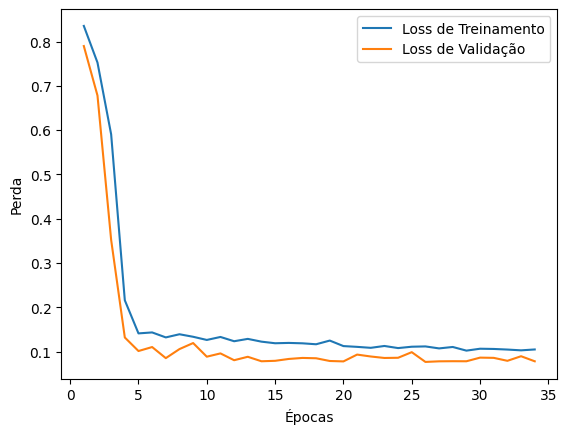

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step


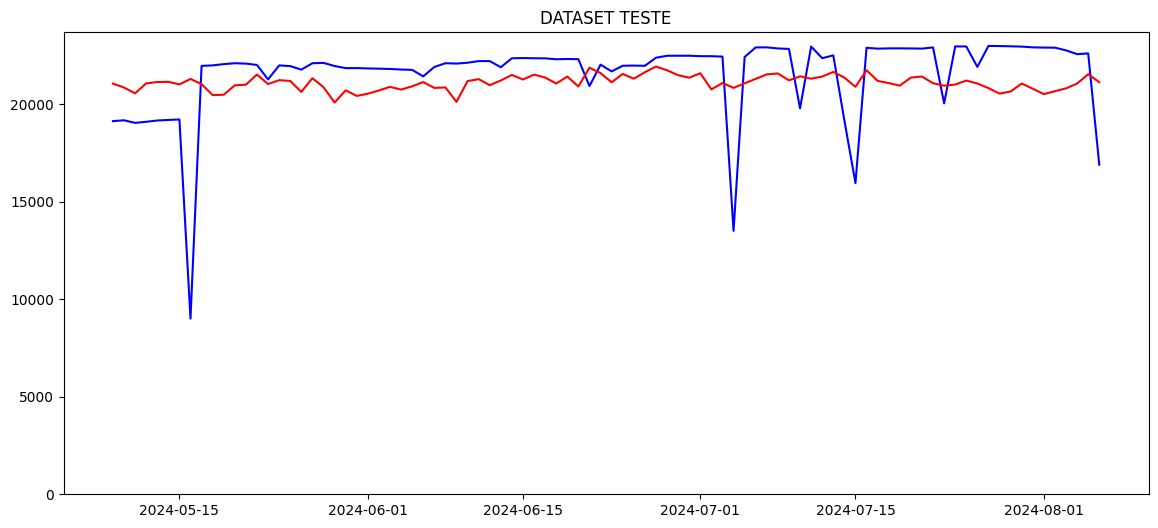

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.7999999999999999.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 733ms/step - loss: 0.8630 - val_loss: 0.8257
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.8185 - val_loss: 0.7888
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.7814 - val_loss: 0.7444
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.7331 - val_loss: 0.6781
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.6613 - val_loss: 0.5675
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.5358 - val_loss: 0.3516
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.3012 - val_loss: 0.0991
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1435 - val_loss: 0.1063
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1578 - val_loss: 0.0802
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1446 - val_loss: 0.0778
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1398 - val_loss: 0.0800
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━

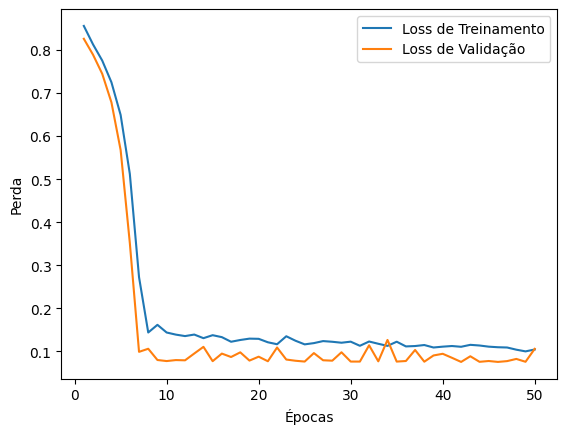

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step


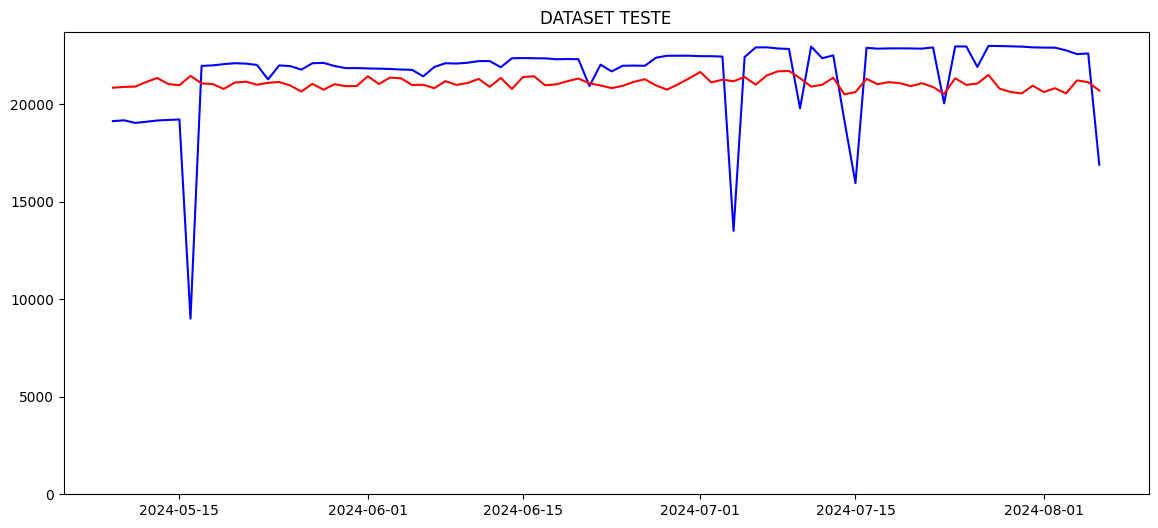

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_2\avaliacao_with_method_split_0.8999999999999999.txt


In [26]:
# for k in range(2,10):
#     model_2 = create_model(config, dataset_type_du, X, y, 'k-fold', k, 0)
#     results(model_2, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_2, k)

tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    model_2 = create_and_train_model(config, dataset_type_du, X, y, 'split', 0, tt_rate)
    results(model_2, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_2, tt_rate)

## **TESTE 03**

Prata I, II, III, Pirapama e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Pirapama);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 03 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [0, 1, 2, 3]
dataset_test_3 = concatenate_selected_datasets(scaled_datasets, indices)

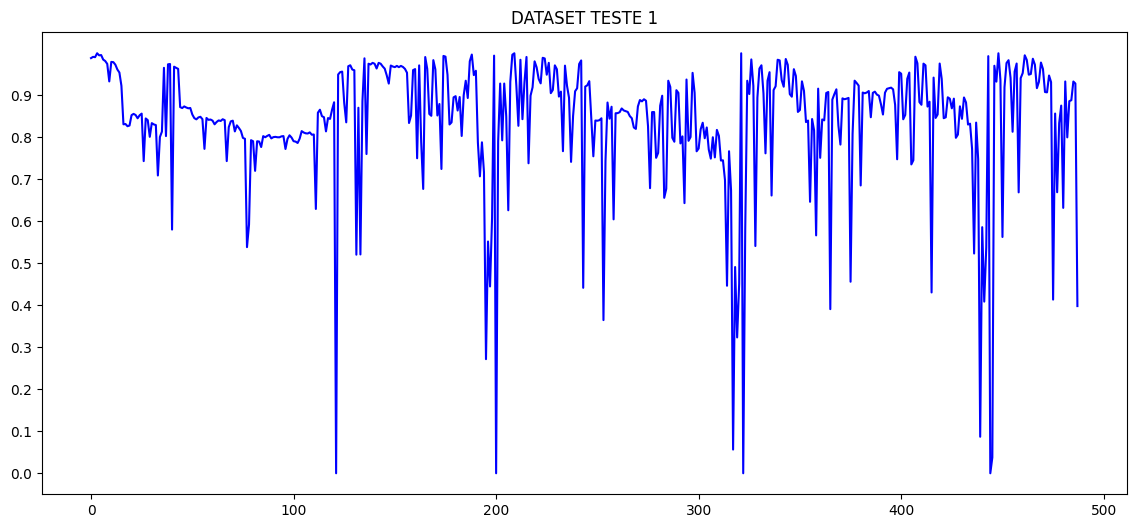

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_3, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_3, y_3 = create_dataset(dataset_test_3, timesteps, output_steps)
X_3 = X_3.reshape(X_3.shape[0], X_3.shape[1], 1)

#model3 = create_model(config, dataset_type_du, X_3, y_3, validation_method, 3)

X shape (458, 1)
y shape (458, 30)



Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.8116 - val_loss: 0.7750
Epoch 2/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.7576 - val_loss: 0.6988
Epoch 3/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6671 - val_loss: 0.5269
Epoch 4/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4513 - val_loss: 0.1954
Epoch 5/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2114 - val_loss: 0.1130
Epoch 6/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1765 - val_loss: 0.1019
Epoch 7/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1725 - val_loss: 0.1017
Epoch 8/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1618 - val_loss: 0.1017
Epoch 9/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1622 - val_loss: 0.1041
Epoch 10/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1577 - val_loss: 0.1014
Epoch 11/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1606 - val_loss: 0.1014
Epoch 12/100000
28/28 ━

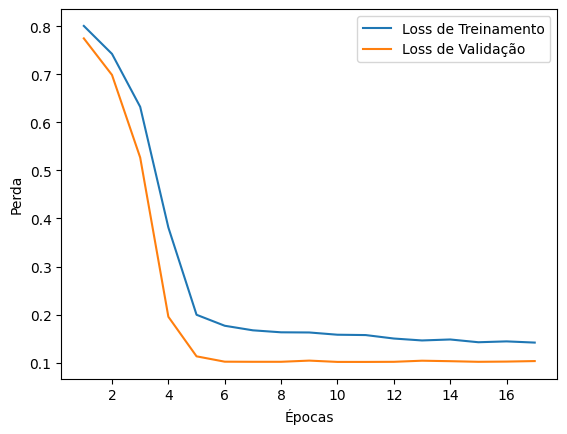

X shape (43, 1)
y shape (43, 30)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.8775 - val_loss: 0.8742
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.8765 - val_loss: 0.8714
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 0.8707 - val_loss: 0.8682
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.8686 - val_loss: 0.8652
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.8672 - val_loss: 0.8625
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.8616 - val_loss: 0.8596
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8627 - val_loss: 0.8568
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8599 - val_loss: 0.8541
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.8538 - val_loss: 0.8509
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.8507 - val_loss: 0.8480
Epoch 11/100000
1/1 

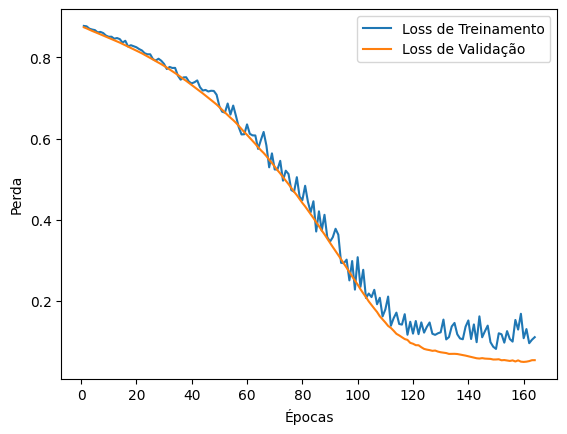

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step


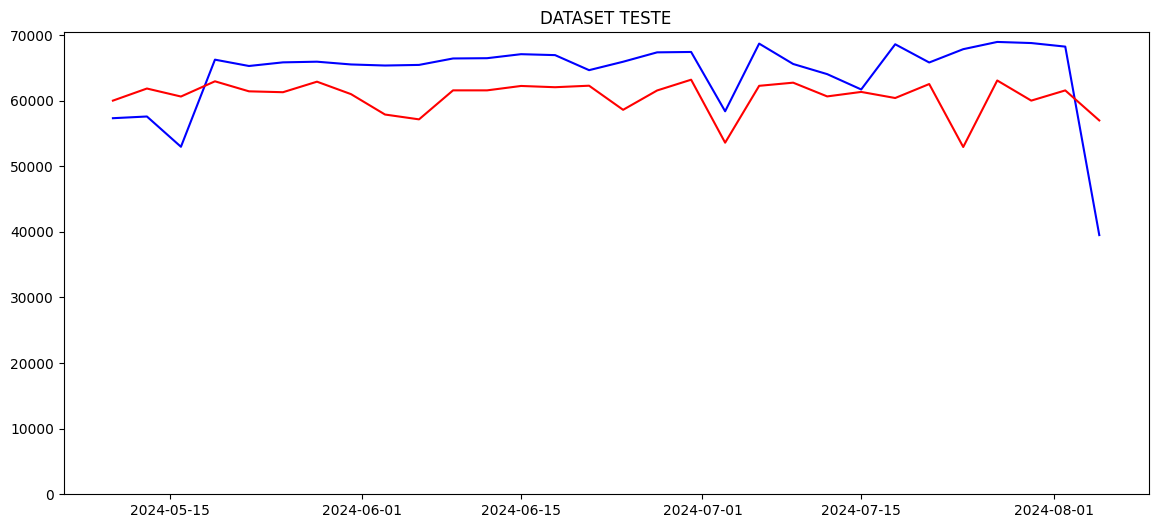

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.1.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.8164 - val_loss: 0.7742
Epoch 2/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.7652 - val_loss: 0.7052
Epoch 3/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6829 - val_loss: 0.5565
Epoch 4/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4993 - val_loss: 0.2445
Epoch 5/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2324 - val_loss: 0.1225
Epoch 6/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1853 - val_loss: 0.1329
Epoch 7/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1768 - val_loss: 0.1070
Epoch 8/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1625 - val_loss: 0.1083
Epoch 9/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1666 - val_loss: 0.1075
Epoch 10/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1679 - val_loss: 0.1129
Epoch 11/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1578 - val_loss: 0.1073
Epoch 12/100000
25/25 ━━━━━

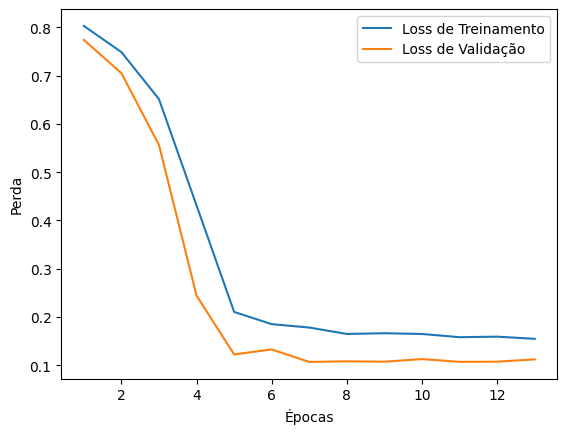

X shape (43, 1)
y shape (43, 30)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - loss: 0.8816 - val_loss: 0.8740
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - loss: 0.8789 - val_loss: 0.8708
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.8750 - val_loss: 0.8676
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 0.8714 - val_loss: 0.8642
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8683 - val_loss: 0.8611
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8667 - val_loss: 0.8576
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.8643 - val_loss: 0.8545
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.8590 - val_loss: 0.8512
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.8560 - val_loss: 0.8478
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8524 - val_loss: 0.8443
Epoch 11/100000
1/1

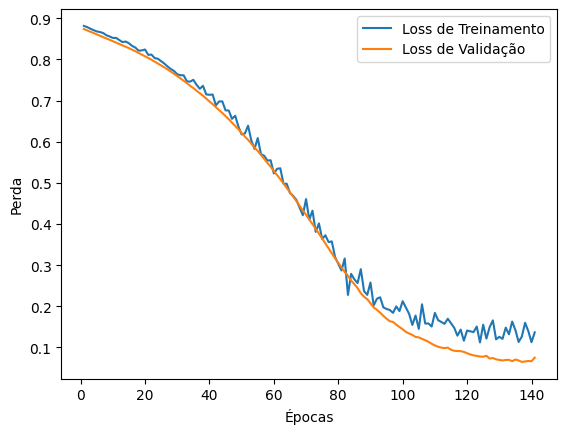

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


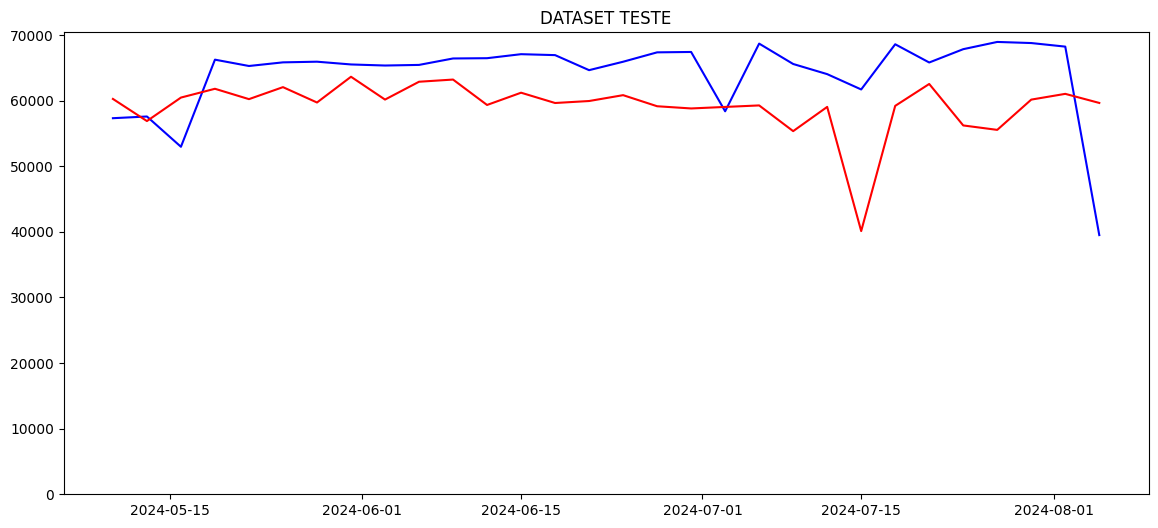

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.2.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 0.8175 - val_loss: 0.7780
Epoch 2/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7745 - val_loss: 0.7263
Epoch 3/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7143 - val_loss: 0.6300
Epoch 4/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5990 - val_loss: 0.4298
Epoch 5/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3661 - val_loss: 0.1594
Epoch 6/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1939 - val_loss: 0.1253
Epoch 7/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1829 - val_loss: 0.1186
Epoch 8/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1710 - val_loss: 0.1194
Epoch 9/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1709 - val_loss: 0.1123
Epoch 10/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1657 - val_loss: 0.1123
Epoch 11/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1579 - val_loss: 0.1118
Epoch 12/100000
22/22 ━━━━━

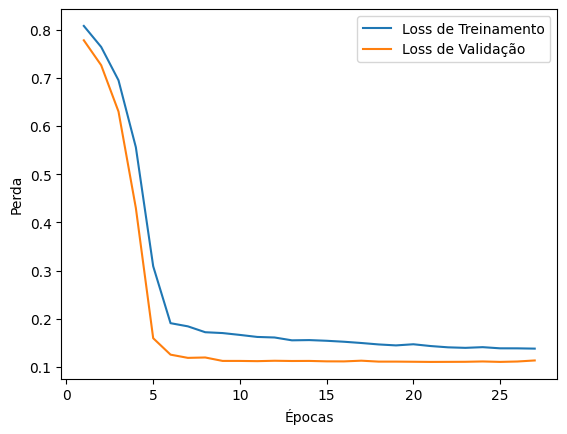

X shape (43, 1)
y shape (43, 30)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.8802 - val_loss: 0.8730
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.8771 - val_loss: 0.8692
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.8736 - val_loss: 0.8654
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8707 - val_loss: 0.8620
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 0.8677 - val_loss: 0.8588
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.8636 - val_loss: 0.8555
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.8595 - val_loss: 0.8522
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.8582 - val_loss: 0.8491
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.8529 - val_loss: 0.8458
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.8514 - val_loss: 0.8427
Epoch 11/100000
1/1

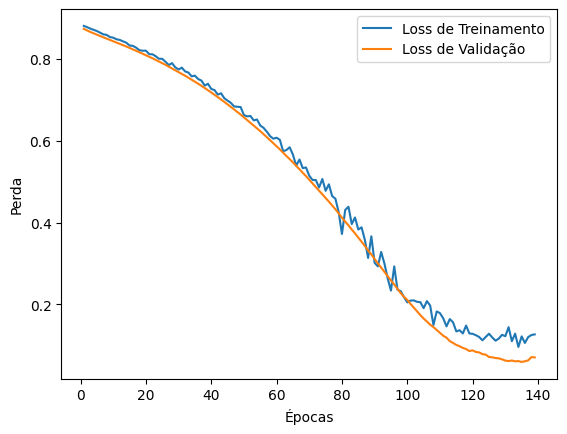

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step


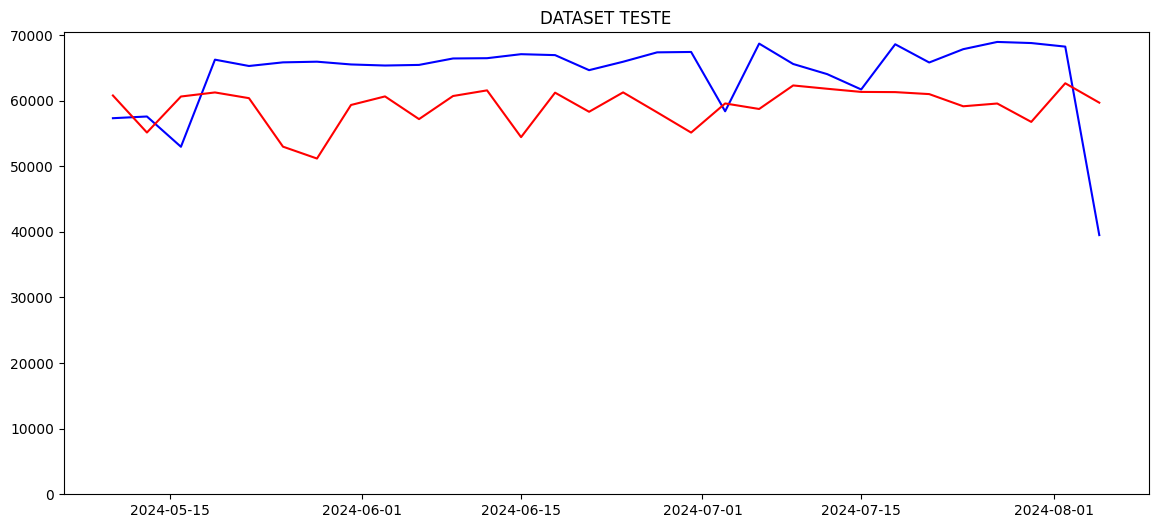

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.30000000000000004.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.8186 - val_loss: 0.7874
Epoch 2/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7812 - val_loss: 0.7462
Epoch 3/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.7357 - val_loss: 0.6786
Epoch 4/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6529 - val_loss: 0.5515
Epoch 5/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4985 - val_loss: 0.3189
Epoch 6/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2725 - val_loss: 0.1540
Epoch 7/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1908 - val_loss: 0.1199
Epoch 8/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1758 - val_loss: 0.1131
Epoch 9/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1702 - val_loss: 0.1121
Epoch 10/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1761 - val_loss: 0.1115
Epoch 11/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1776 - val_loss: 0.1150
Epoch 12/100000
19/1

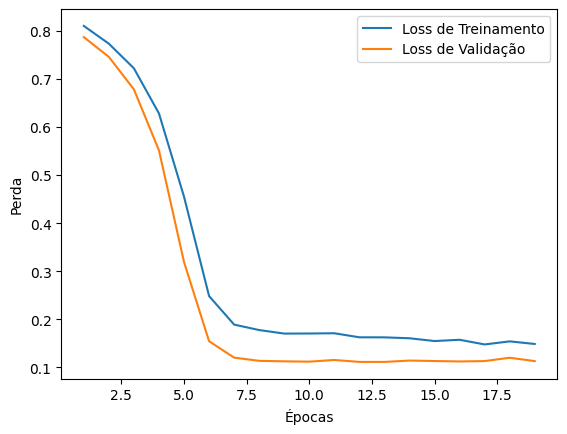

X shape (43, 1)
y shape (43, 30)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 992ms/step - loss: 0.8768 - val_loss: 0.8694
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8705 - val_loss: 0.8620
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8636 - val_loss: 0.8550
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8563 - val_loss: 0.8477
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8514 - val_loss: 0.8408
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8423 - val_loss: 0.8337
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8385 - val_loss: 0.8265
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8279 - val_loss: 0.8195
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8213 - val_loss: 0.8119
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8169 - val_loss: 0.8039
Epoch 11/100000
2/2 ━━━━━

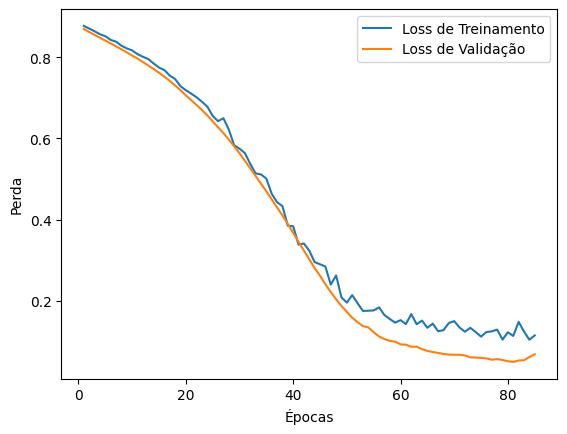

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step


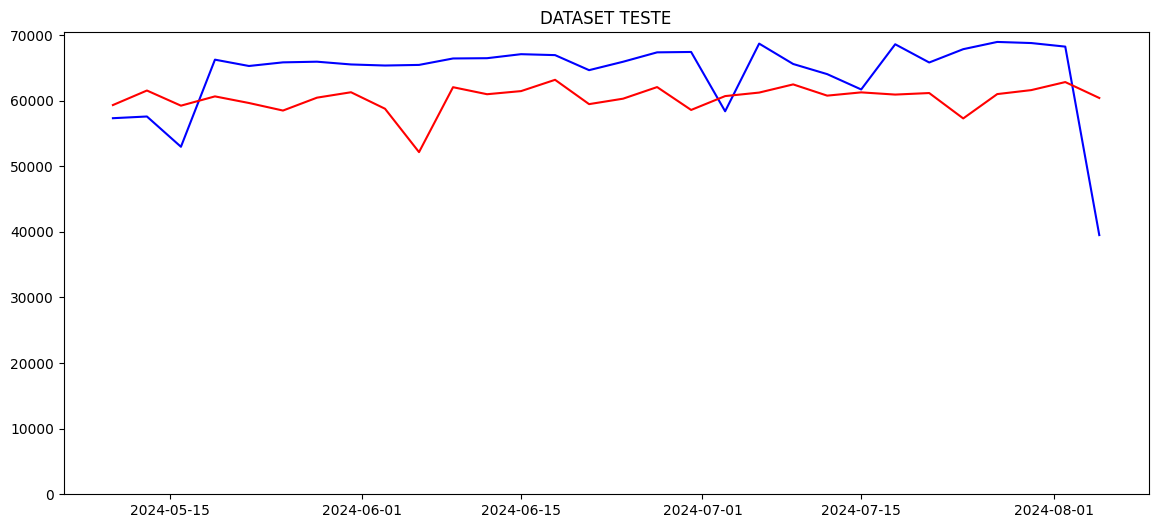

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.4.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 0.8200 - val_loss: 0.7941
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.7873 - val_loss: 0.7607
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7506 - val_loss: 0.7112
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6950 - val_loss: 0.6291
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6006 - val_loss: 0.4867
Epoch 6/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4435 - val_loss: 0.2720
Epoch 7/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2504 - val_loss: 0.1460
Epoch 8/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1959 - val_loss: 0.1213
Epoch 9/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1751 - val_loss: 0.1164
Epoch 10/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1643 - val_loss: 0.1155
Epoch 11/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1693 - val_loss: 0.1178
Epoch 12/100000
16

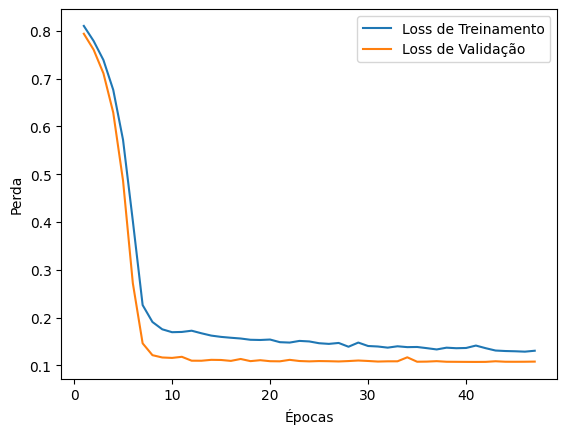

X shape (43, 1)
y shape (43, 30)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.8757 - val_loss: 0.8710
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.8692 - val_loss: 0.8646
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.8626 - val_loss: 0.8585
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.8583 - val_loss: 0.8524
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 0.8507 - val_loss: 0.8463
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8452 - val_loss: 0.8403
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8410 - val_loss: 0.8343
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8345 - val_loss: 0.8283
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8272 - val_loss: 0.8220
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8226 - val_loss: 0.8155
Epoch 11/100000
2/2 ━━━━━━━

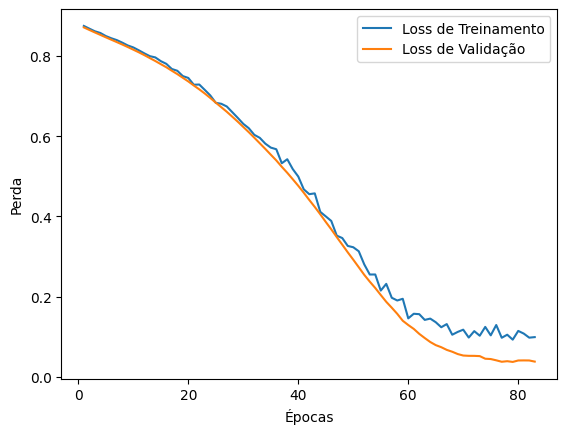

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step


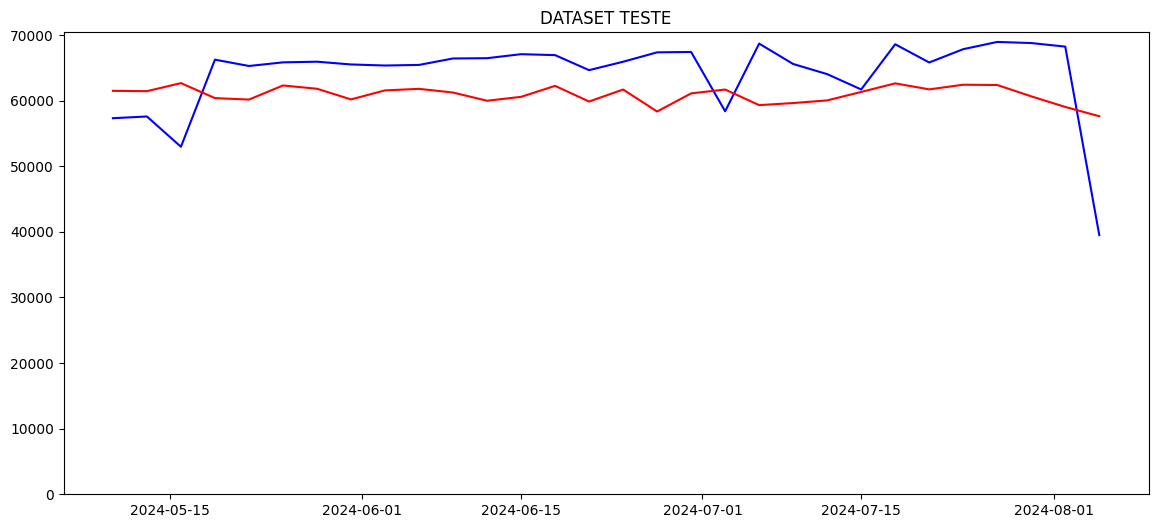

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.5.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - loss: 0.8197 - val_loss: 0.8005
Epoch 2/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7944 - val_loss: 0.7775
Epoch 3/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7701 - val_loss: 0.7489
Epoch 4/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7403 - val_loss: 0.7105
Epoch 5/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6966 - val_loss: 0.6543
Epoch 6/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6350 - val_loss: 0.5713
Epoch 7/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5418 - val_loss: 0.4430
Epoch 8/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3955 - val_loss: 0.2734
Epoch 9/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2518 - val_loss: 0.1833
Epoch 10/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2027 - val_loss: 0.1325
Epoch 11/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1829 - val_loss: 0.1201
Epoch 12/100000
13/

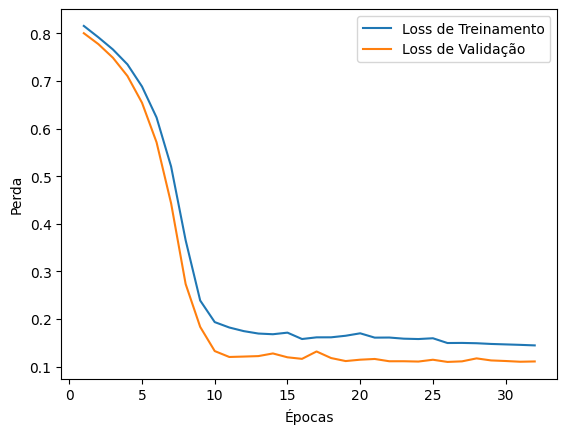

X shape (43, 1)
y shape (43, 30)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 992ms/step - loss: 0.8782 - val_loss: 0.8716
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.8717 - val_loss: 0.8656
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8660 - val_loss: 0.8595
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.8607 - val_loss: 0.8533
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8534 - val_loss: 0.8472
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8487 - val_loss: 0.8411
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8412 - val_loss: 0.8346
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8361 - val_loss: 0.8282
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8317 - val_loss: 0.8215
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8222 - val_loss: 0.8141
Epoch 11/100000
2/2 ━━━━━

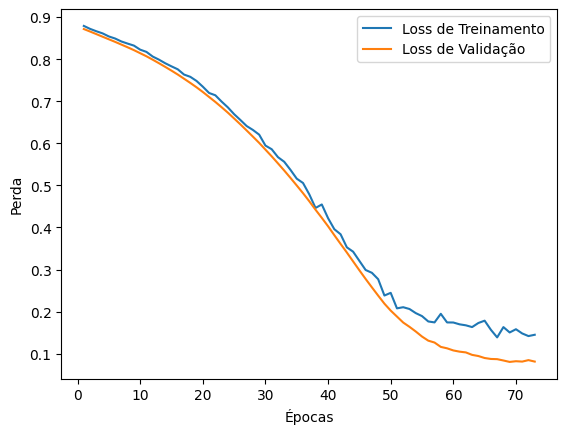

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step


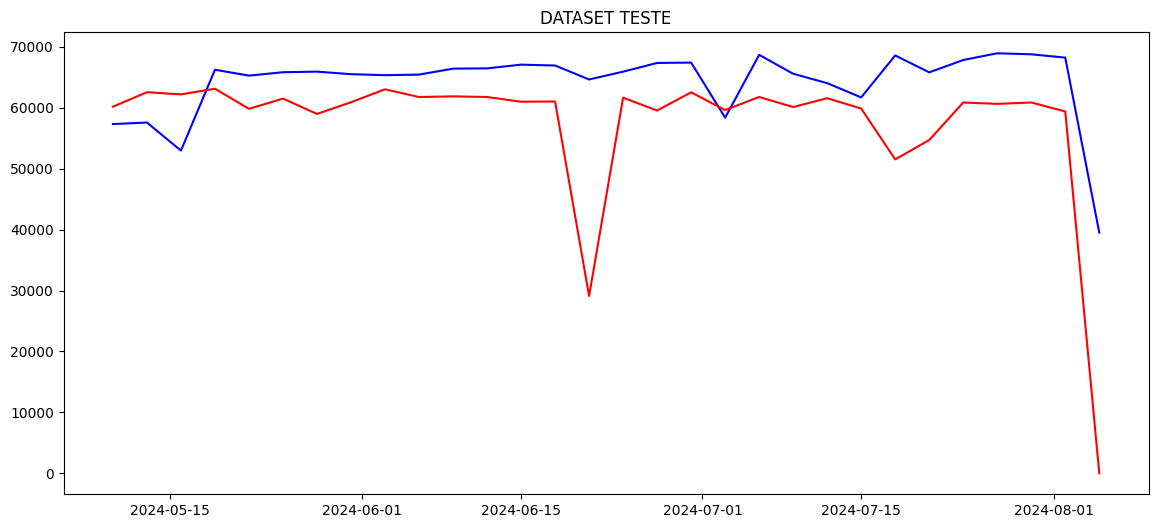

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.6.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.8210 - val_loss: 0.8061
Epoch 2/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.7999 - val_loss: 0.7883
Epoch 3/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7821 - val_loss: 0.7687
Epoch 4/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7605 - val_loss: 0.7445
Epoch 5/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7341 - val_loss: 0.7140
Epoch 6/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7034 - val_loss: 0.6736
Epoch 7/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6595 - val_loss: 0.6184
Epoch 8/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5958 - val_loss: 0.5394
Epoch 9/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5112 - val_loss: 0.4331
Epoch 10/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4109 - val_loss: 0.3001
Epoch 11/100000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2850 - val_loss: 0.1906
Epoch 12/100000
10

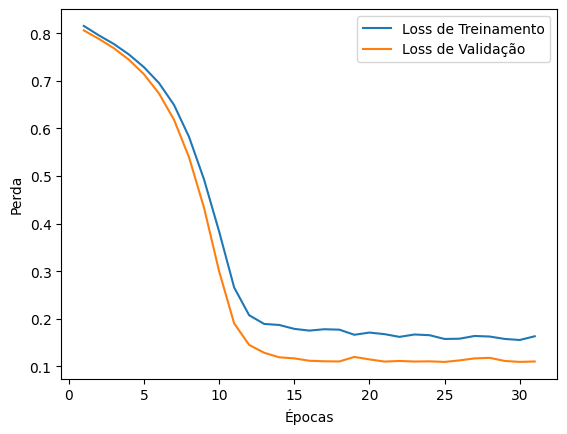

X shape (43, 1)
y shape (43, 30)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_39 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_40 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 971ms/step - loss: 0.8760 - val_loss: 0.8712
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8693 - val_loss: 0.8641
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8633 - val_loss: 0.8576
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.8574 - val_loss: 0.8514
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8502 - val_loss: 0.8448
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8456 - val_loss: 0.8383
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8376 - val_loss: 0.8313
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.8323 - val_loss: 0.8241
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.8251 - val_loss: 0.8165
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8170 - val_loss: 0.8085
Epoch 11/100000
2/2 ━━━━━

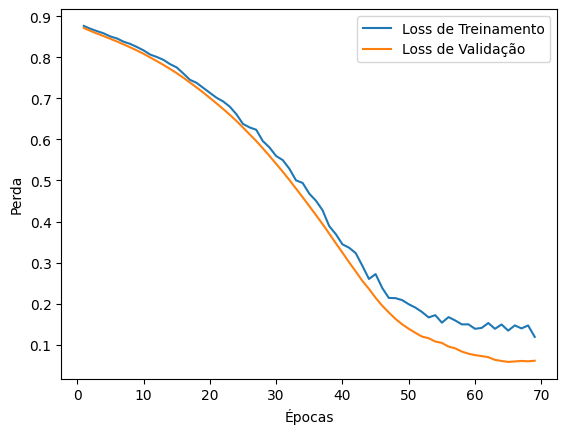

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step


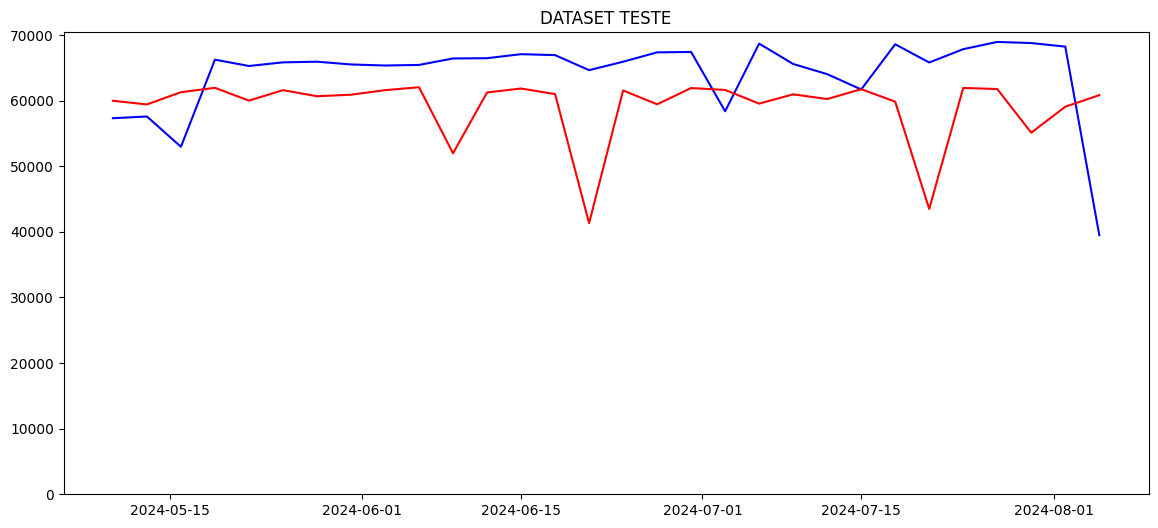

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.7.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_43 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_44 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - loss: 0.8130 - val_loss: 0.8148
Epoch 2/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.7986 - val_loss: 0.8034
Epoch 3/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.7873 - val_loss: 0.7924
Epoch 4/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7766 - val_loss: 0.7805
Epoch 5/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.7648 - val_loss: 0.7675
Epoch 6/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7511 - val_loss: 0.7529
Epoch 7/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7352 - val_loss: 0.7356
Epoch 8/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.7182 - val_loss: 0.7155
Epoch 9/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6965 - val_loss: 0.6918
Epoch 10/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6728 - val_loss: 0.6640
Epoch 11/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6459 - val_loss: 0.6303
Epoch 12/100000
7/7 ━━━━━━━━━━━━━━━━━━━━

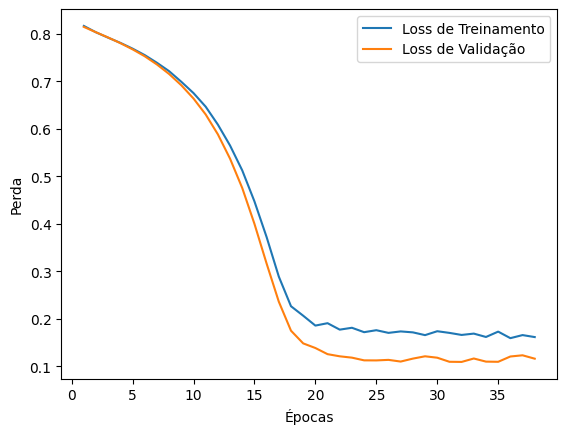

X shape (43, 1)
y shape (43, 30)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_45 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_46 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_47 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 496ms/step - loss: 0.8764 - val_loss: 0.8658
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8692 - val_loss: 0.8573
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8606 - val_loss: 0.8480
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8506 - val_loss: 0.8375
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.8423 - val_loss: 0.8275
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8318 - val_loss: 0.8171
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8206 - val_loss: 0.8063
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8098 - val_loss: 0.7942
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7992 - val_loss: 0.7811
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.7851 - val_loss: 0.7673
Epoch 11/100000
3/3 ━━━━━

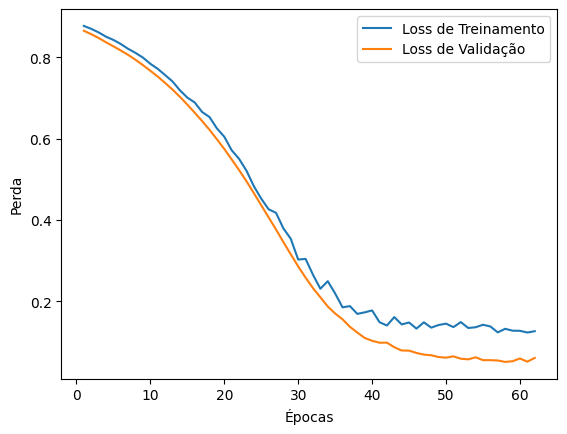

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


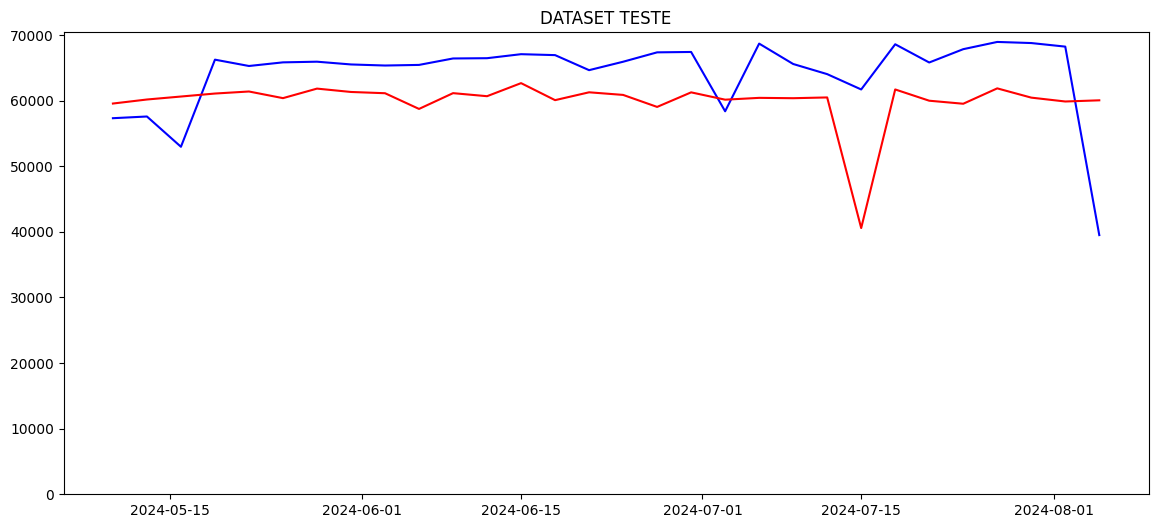

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.7999999999999999.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 560ms/step - loss: 0.8246 - val_loss: 0.8212
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.8155 - val_loss: 0.8147
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8096 - val_loss: 0.8092
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.8040 - val_loss: 0.8041
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.7986 - val_loss: 0.7989
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.7938 - val_loss: 0.7939
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.7883 - val_loss: 0.7885
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.7833 - val_loss: 0.7831
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.7774 - val_loss: 0.7773
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.7720 - val_loss: 0.7712
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.7660 - val_loss: 0.7649
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━

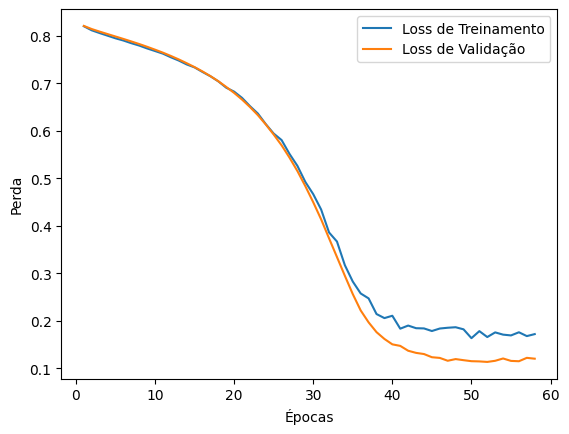

X shape (43, 1)
y shape (43, 30)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_51 (LSTM)                  │ (None, 1, 44)          │         8,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 1, 44)          │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 1, 44)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 44)             │        15,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │         1,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,774 (159.27 KB)

 Trainable params: 40,774 (159.27 KB)

 Non-trainable params: 0 (0.00 B)

(1, 176)
(44, 176)
(176,)
(44, 176)
(44, 176)
(176,)
LSTM 1 treinable:  False
LSTM 2 treinable:  False
Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 499ms/step - loss: 0.8707 - val_loss: 0.8529
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8610 - val_loss: 0.8433
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8509 - val_loss: 0.8335
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8405 - val_loss: 0.8231
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8315 - val_loss: 0.8124
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8187 - val_loss: 0.8013
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8058 - val_loss: 0.7889
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.7959 - val_loss: 0.7761
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7803 - val_loss: 0.7615
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7652 - val_loss: 0.7466
Epoch 11/100000
3/3 ━━━━━

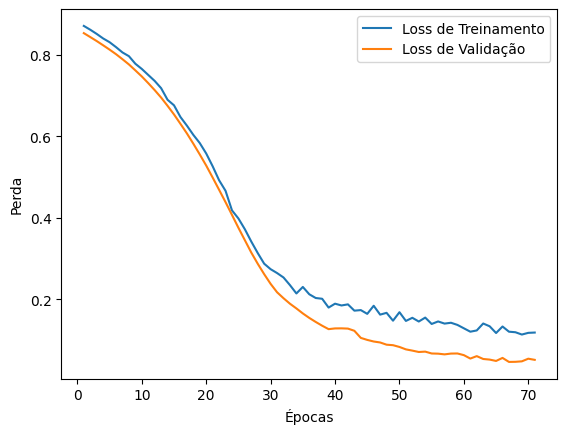

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step


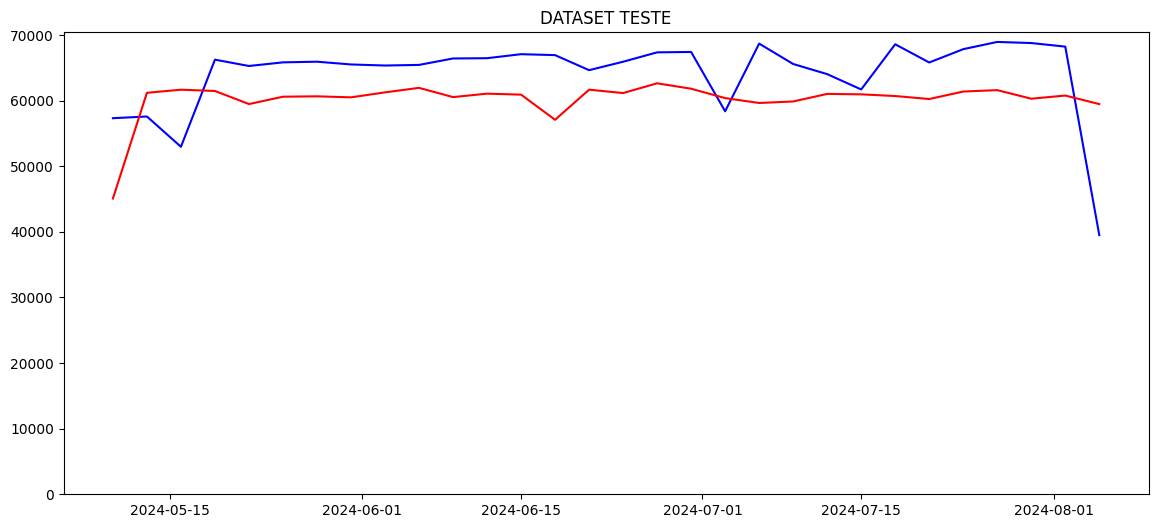

Output salvo em: Resultados_PSO/pso_du/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split_0.8999999999999999.txt


In [26]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model3 = train_model(X_3, y_3, validation_method, k, tt_rate=0)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# Treinamento com train-test split
tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    print("\nTraining with train-test split")
    validation_method = 'split'
    model3 = create_and_train_model(config, dataset_type_du, X_3, y_3, validation_method, None, tt_rate)
    transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, tt_rate)

In [27]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento3 = model3.get_weights()
# pesos_LSTM1_t3 = model3.layers[0].get_weights()
# pesos_LSTM2_t3 = model3.layers[2].get_weights()
# pesos_LSTM3_t3 = model3.layers[4].get_weights()
# pesos_DENSE_t3 = model3.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'), *pesos_LSTM1_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'), *pesos_LSTM2_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'), *pesos_LSTM3_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_DENSE_t3_{validation_method}.npz'), *pesos_DENSE_t3)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_modelo_t3_{validation_method}.npz'), *pesos_treinamento3)

In [28]:
# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'))
# pesos_carregados_LSTM2_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'))
# pesos_carregados_LSTM3_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'))

In [29]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model3_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model3_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model3_ft.add(Dropout(0.3))

# model3_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model3_ft.summary()

In [30]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz')
# caminho_LSTM2_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz')
# caminho_LSTM3_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz')

# carregar_e_aplicar_pesos(model3_ft, caminho_LSTM1_t3, caminho_LSTM2_t3, caminho_LSTM3_t3)

In [31]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t3[0], model3_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t3[1], model3_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t3[2], model3_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t3[0], model3_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t3[1], model3_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t3[2], model3_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# # ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t3[0], model3_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t3[1], model3_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t3[2], model3_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)

In [32]:
# congelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [33]:
# descongelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [34]:
# pred = model3_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 3")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_3, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [35]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_3)

## **Teste 04**

Prata I, II, III, Pirapama e Duas Unas. Ações a serem testadas:

1. Padronizar cada dataset em separado (Prata I, II, III, Pirapama e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 04 ###

indices = [0, 1, 2, 3, 4]
dataset_test_4 = concatenate_selected_datasets(scaled_datasets, indices)

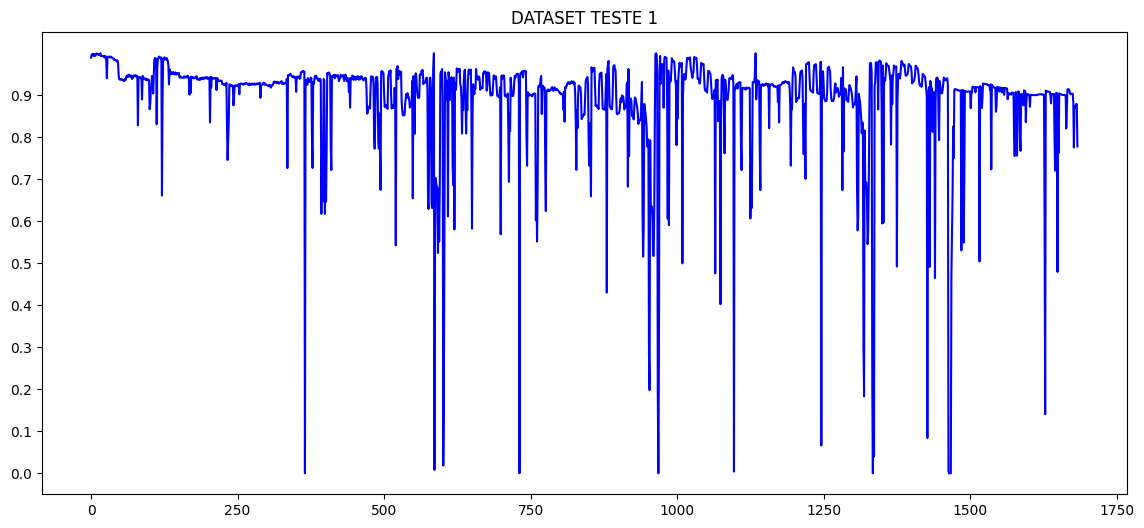

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_4, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (1594, 1)
y shape (1594, 90)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - loss: 0.7095 - val_loss: 0.0963
Epoch 2/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1285 - val_loss: 0.0891
Epoch 3/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1170 - val_loss: 0.0835
Epoch 4/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1076 - val_loss: 0.0842
Epoch 5/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1054 - val_loss: 0.0724
Epoch 6/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0971 - val_loss: 0.0707
Epoch 7/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0934 - val_loss: 0.0701
Epoch 8/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0897 - val_loss: 0.0943
Epoch 9/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0884 - val_loss: 0.0919
Epoch 10/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0871 - val_loss: 0.0697
Epoch 11/100000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0824 - val_loss: 0.0697
Epoch 12/100000
32

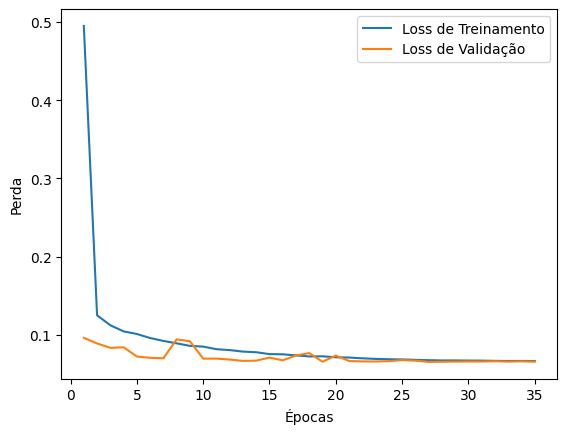

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 978ms/step


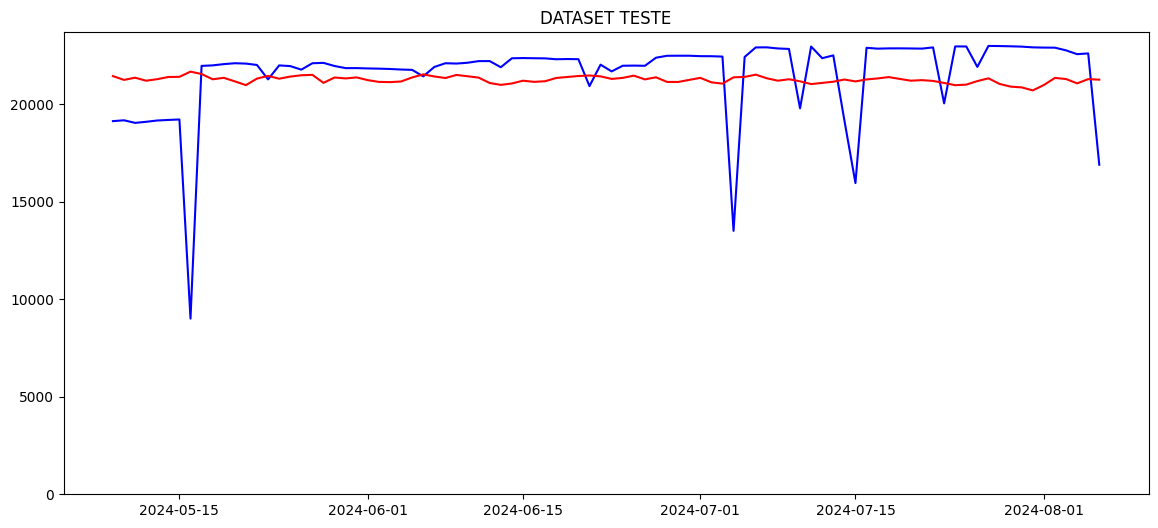

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.1.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.7410 - val_loss: 0.0683
Epoch 2/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1270 - val_loss: 0.0704
Epoch 3/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1202 - val_loss: 0.0765
Epoch 4/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1093 - val_loss: 0.0813
Epoch 5/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1080 - val_loss: 0.0673
Epoch 6/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0990 - val_loss: 0.0736
Epoch 7/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0967 - val_loss: 0.0716
Epoch 8/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0945 - val_loss: 0.0675
Epoch 9/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0906 - val_loss: 0.0661
Epoch 10/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0861 - val_loss: 0.0662
Epoch 11/100000
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0850 - val_loss: 0.0701
Epoch 12/100000
28

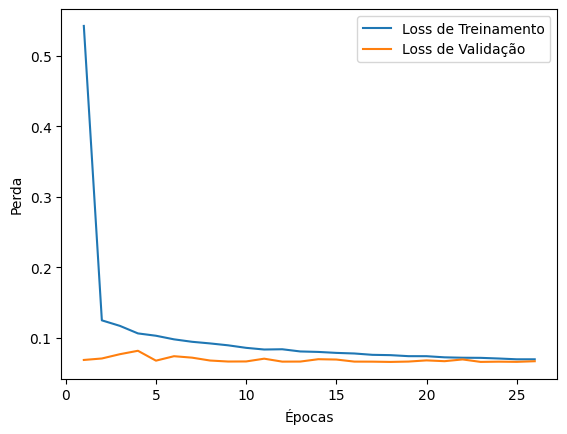

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step


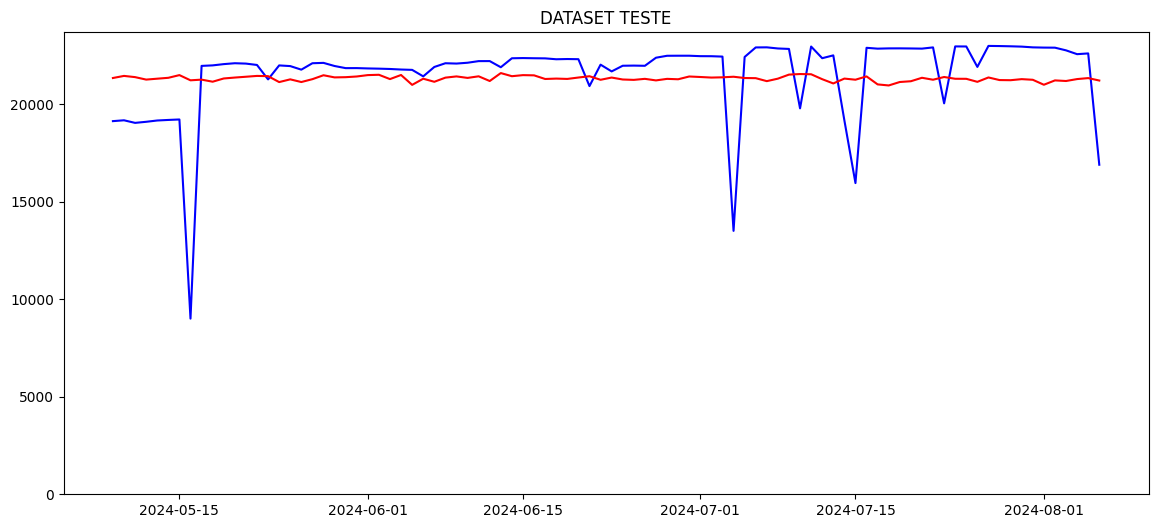

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - loss: 0.7665 - val_loss: 0.0779
Epoch 2/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1329 - val_loss: 0.0768
Epoch 3/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1166 - val_loss: 0.0737
Epoch 4/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1154 - val_loss: 0.0783
Epoch 5/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1081 - val_loss: 0.0890
Epoch 6/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1022 - val_loss: 0.0801
Epoch 7/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0967 - val_loss: 0.0817
Epoch 8/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0951 - val_loss: 0.0678
Epoch 9/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0916 - val_loss: 0.0780
Epoch 10/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0887 - val_loss: 0.0724
Epoch 11/100000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0871 - val_loss: 0.0686
Epoch 12/100000
25

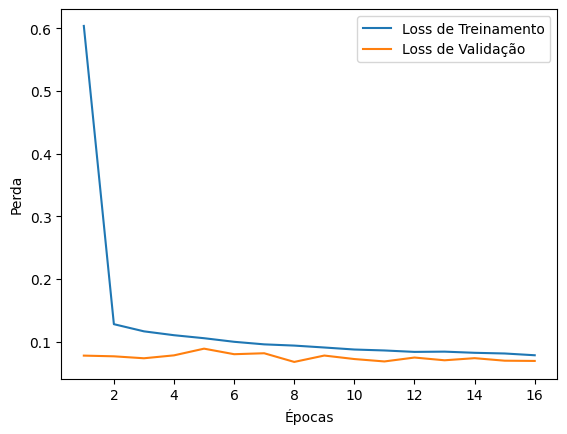

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step


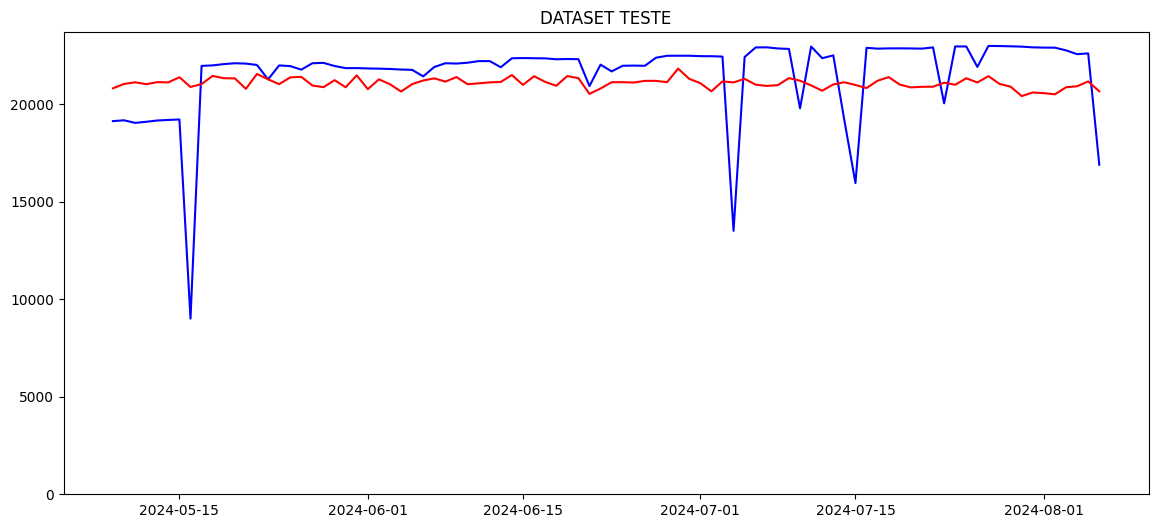

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.30000000000000004.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - loss: 0.7896 - val_loss: 0.0844
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1358 - val_loss: 0.1019
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1256 - val_loss: 0.0720
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1168 - val_loss: 0.0693
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1105 - val_loss: 0.0811
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1067 - val_loss: 0.0681
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1015 - val_loss: 0.0891
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1013 - val_loss: 0.0730
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0973 - val_loss: 0.0760
Epoch 10/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0952 - val_loss: 0.0705
Epoch 11/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0890 - val_loss: 0.0667
Epoch 12/100000
21

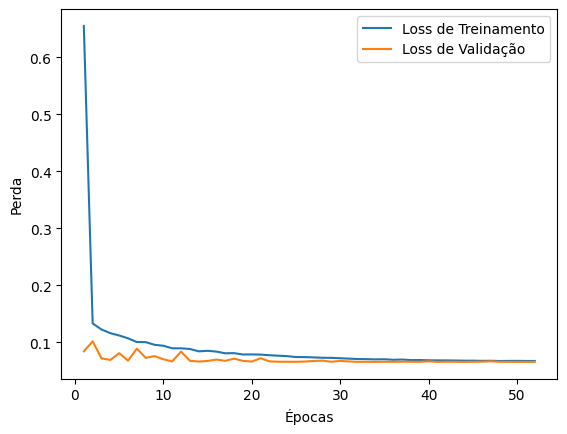

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step


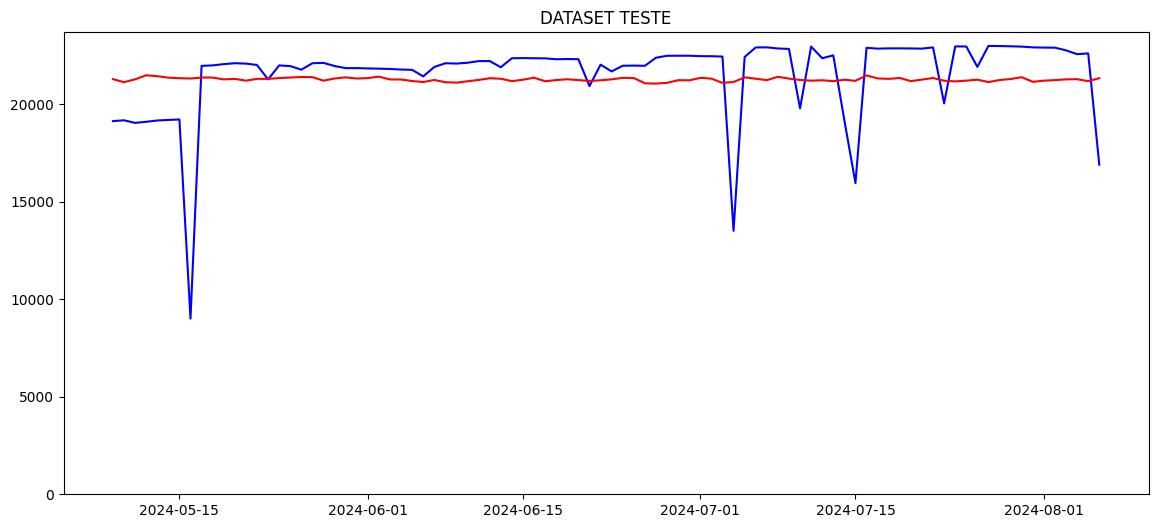

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 0.8168 - val_loss: 0.3634
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2003 - val_loss: 0.0968
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1303 - val_loss: 0.0720
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1176 - val_loss: 0.0702
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1179 - val_loss: 0.0712
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1121 - val_loss: 0.0930
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1047 - val_loss: 0.0723
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1017 - val_loss: 0.0677
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0970 - val_loss: 0.0705
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0929 - val_loss: 0.0765
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0919 - val_loss: 0.0699
Epoch 12/100000
18

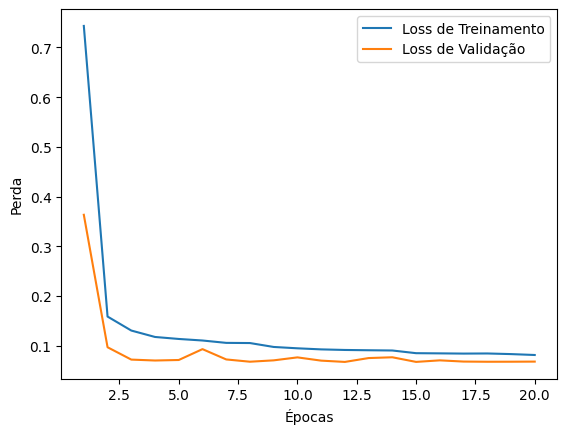

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


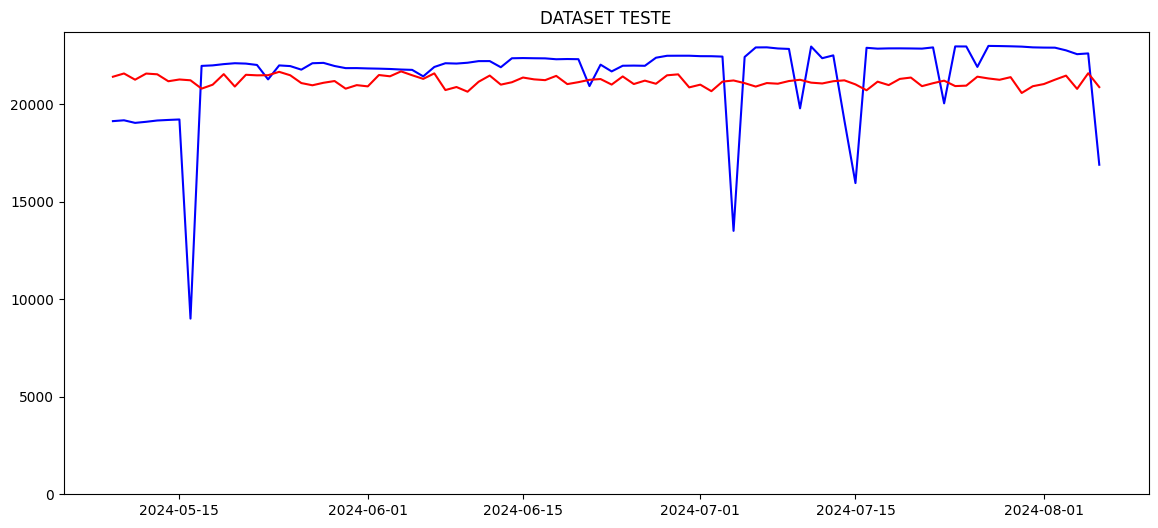

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.8332 - val_loss: 0.6232
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.4200 - val_loss: 0.1086
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1305 - val_loss: 0.0989
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1249 - val_loss: 0.0734
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1198 - val_loss: 0.0847
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1134 - val_loss: 0.0739
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1099 - val_loss: 0.0710
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1085 - val_loss: 0.0673
Epoch 9/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1033 - val_loss: 0.0686
Epoch 10/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0985 - val_loss: 0.0671
Epoch 11/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0988 - val_loss: 0.0952
Epoch 12/100000
1

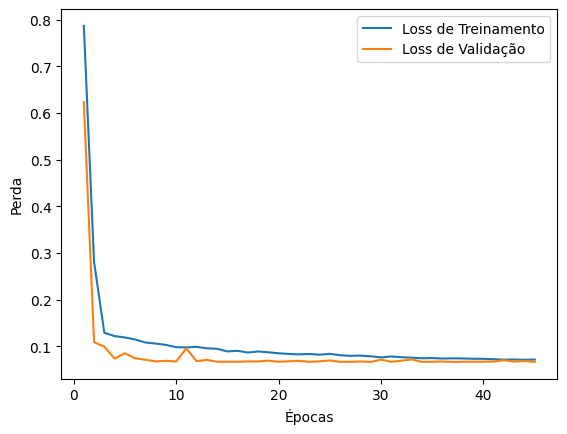

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step


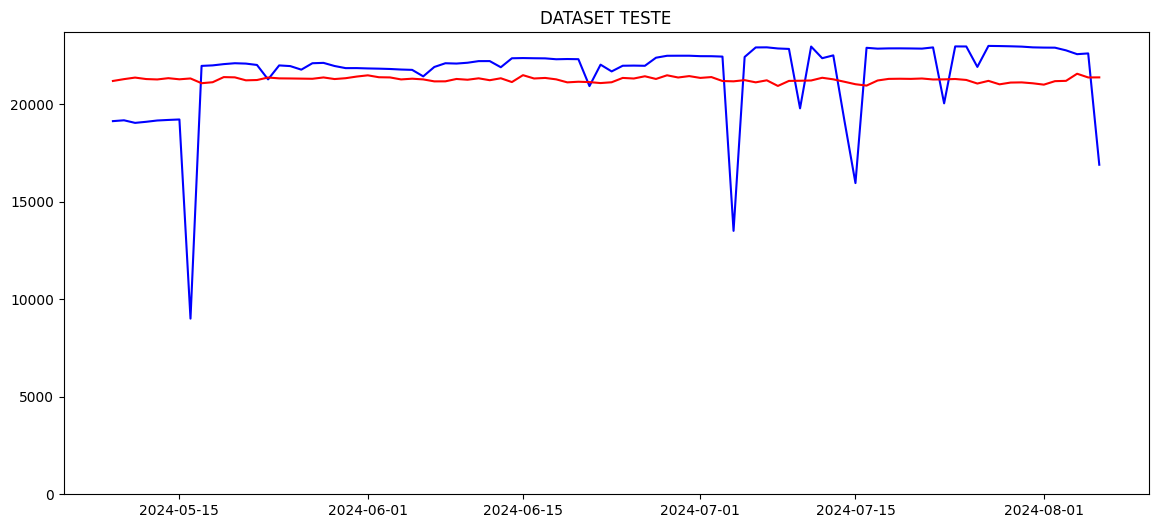

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - loss: 0.8437 - val_loss: 0.7162
Epoch 2/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6044 - val_loss: 0.0801
Epoch 3/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1321 - val_loss: 0.0957
Epoch 4/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1333 - val_loss: 0.0689
Epoch 5/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1275 - val_loss: 0.1014
Epoch 6/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1206 - val_loss: 0.0784
Epoch 7/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1216 - val_loss: 0.0718
Epoch 8/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1131 - val_loss: 0.0703
Epoch 9/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1101 - val_loss: 0.0680
Epoch 10/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1092 - val_loss: 0.0683
Epoch 11/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1039 - val_loss: 0.1063
Epoch 12/100000
1

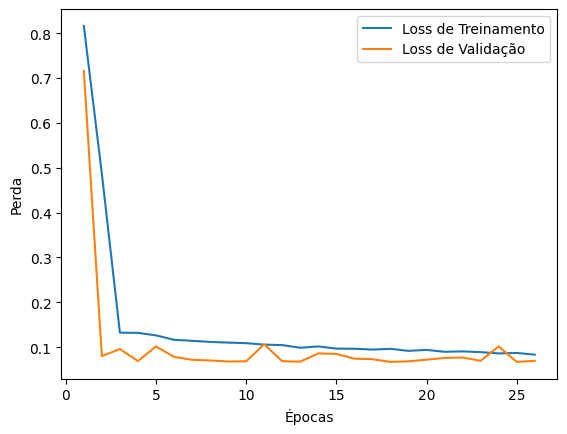

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step


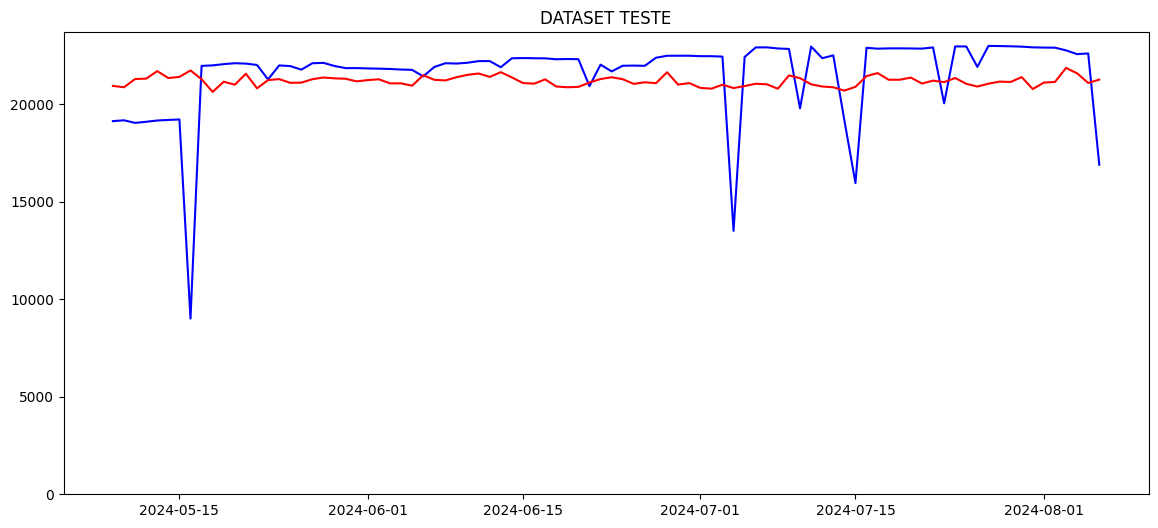

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_30 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - loss: 0.8591 - val_loss: 0.7876
Epoch 2/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 0.7580 - val_loss: 0.6192
Epoch 3/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5144 - val_loss: 0.0918
Epoch 4/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1362 - val_loss: 0.1078
Epoch 5/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1276 - val_loss: 0.0776
Epoch 6/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1253 - val_loss: 0.0788
Epoch 7/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1254 - val_loss: 0.0673
Epoch 8/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1228 - val_loss: 0.0890
Epoch 9/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1172 - val_loss: 0.0735
Epoch 10/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1248 - val_loss: 0.0781
Epoch 11/100000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1106 - val_loss: 0.0913
Epoch 12/100000
7/7 ━━━━━━━━━━━━━━━━━━

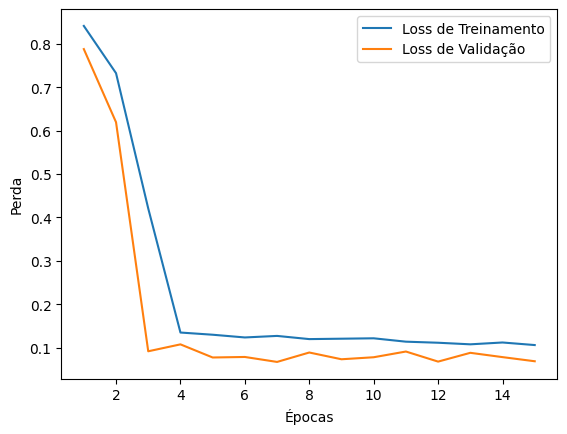

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step


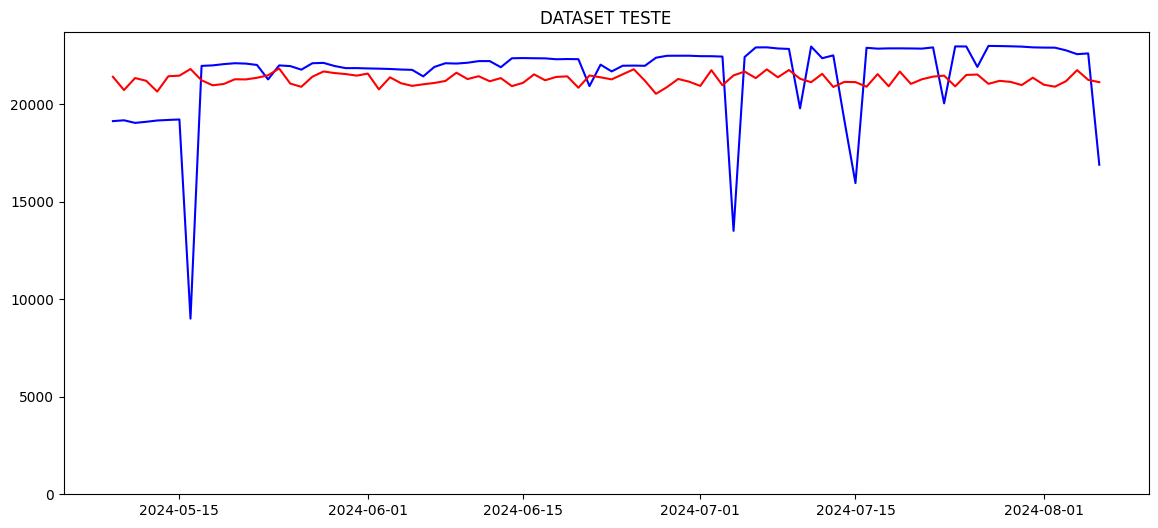

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.7999999999999999.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 1, 75)          │        23,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_34 (LSTM)                  │ (None, 1, 75)          │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 75)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 90)             │         6,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,840 (647.81 KB)

 Trainable params: 165,840 (647.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 503ms/step - loss: 0.8734 - val_loss: 0.8246
Epoch 2/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.8170 - val_loss: 0.7715
Epoch 3/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.7591 - val_loss: 0.6867
Epoch 4/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.6617 - val_loss: 0.5158
Epoch 5/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4448 - val_loss: 0.1238
Epoch 6/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1452 - val_loss: 0.1051
Epoch 7/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1515 - val_loss: 0.1183
Epoch 8/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1333 - val_loss: 0.0951
Epoch 9/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1269 - val_loss: 0.0703
Epoch 10/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1233 - val_loss: 0.0902
Epoch 11/100000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1251 - val_loss: 0.1074
Epoch 12/100000
4/4 ━━━━━━━━━━━━━━━━━━━

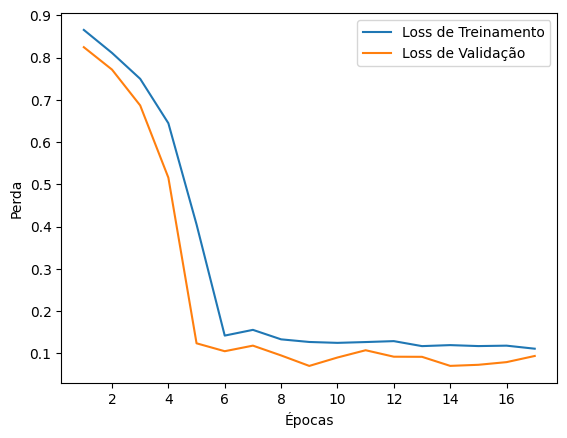

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step


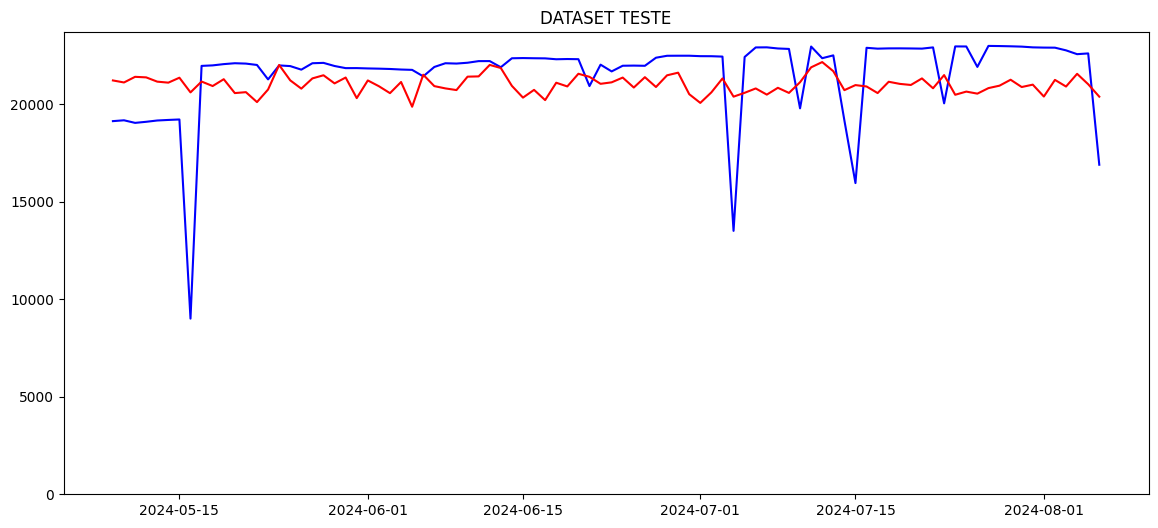

Output salvo em: Resultados_PSO/pso_du/1_days/avaliacao_testes/teste_4\avaliacao_with_method_split_0.8999999999999999.txt


In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_4, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

# for k in range(2,10):
#     model_4 = create_model(config, dataset_type_du, X, y, 'k-fold', k, 0)
#     results(model_4, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_4, k)

tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    model_4 = create_and_train_model(config, dataset_type_du, X, y, 'split', 0, tt_rate)
    results(model_4, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_4, tt_rate)

#model_4 = create_model(config, dataset_type_du, X, y, validation_method, 5)